In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.0)

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
# ============================================================
# Load Training Dataset
# ============================================================

train = pd.read_csv("Train-1542865627584.csv")

beneficiary = pd.read_csv(
    "Train_Beneficiarydata-1542865627584.csv"
)

inpatient = pd.read_csv(
    "Train_Inpatientdata-1542865627584.csv"
)

outpatient = pd.read_csv(
    "Train_Outpatientdata-1542865627584.csv"
)

print("Training Files Loaded Successfully")

Training Files Loaded Successfully


In [5]:
# ============================================================
# Load Unseen Dataset
# ============================================================

unseen = pd.read_csv("Unseen-1542969243754.csv")

unseen_beneficiary = pd.read_csv(
    "Unseen_Beneficiarydata-1542969243754.csv"
)

unseen_inpatient = pd.read_csv(
    "Unseen_Inpatientdata-1542969243754.csv"
)

unseen_outpatient = pd.read_csv(
    "Unseen_Outpatientdata-1542969243754.csv"
)

print("Unseen Files Loaded Successfully")

Unseen Files Loaded Successfully


In [6]:
# Dataset Dimensions
datasets = {
    "Train": train,
    "Beneficiary": beneficiary,
    "Inpatient": inpatient,
    "Outpatient": outpatient,
    "Unseen": unseen,
    "Unseen Beneficiary": unseen_beneficiary,
    "Unseen Inpatient": unseen_inpatient,
    "Unseen Outpatient": unseen_outpatient
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print("Shape :", df.shape)
    print(df.head())

Train
Shape : (5410, 2)
   Provider PotentialFraud
0  PRV51001             No
1  PRV51003            Yes
2  PRV51004             No
3  PRV51005            Yes
4  PRV51007             No
Beneficiary
Shape : (138556, 25)
      BeneID         DOB  DOD  Gender  Race RenalDiseaseIndicator  State  \
0  BENE11001  1943-01-01  NaN       1     1                     0     39   
1  BENE11002  1936-09-01  NaN       2     1                     0     39   
2  BENE11003  1936-08-01  NaN       1     1                     0     52   
3  BENE11004  1922-07-01  NaN       1     1                     0     39   
4  BENE11005  1935-09-01  NaN       1     1                     0     24   

   County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ChronicCond_Alzheimer  \
0     230                   12                   12                      1   
1     280                   12                   12                      2   
2     590                   12                   12                      1   
3     270   

In [7]:
# Data Information
for name, df in datasets.items():

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    display(df.info())



Train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Provider        5410 non-null   object
 1   PotentialFraud  5410 non-null   object
dtypes: object(2)
memory usage: 84.7+ KB


None



Beneficiary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   BeneID                           138556 non-null  object
 1   DOB                              138556 non-null  object
 2   DOD                              1421 non-null    object
 3   Gender                           138556 non-null  int64 
 4   Race                             138556 non-null  int64 
 5   RenalDiseaseIndicator            138556 non-null  object
 6   State                            138556 non-null  int64 
 7   County                           138556 non-null  int64 
 8   NoOfMonths_PartACov              138556 non-null  int64 
 9   NoOfMonths_PartBCov              138556 non-null  int64 
 10  ChronicCond_Alzheimer            138556 non-null  int64 
 11  ChronicCond_Heartfailure         138556 non-null  int64 
 12  Ch

None



Inpatient
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40474 entries, 0 to 40473
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   BeneID                  40474 non-null  object 
 1   ClaimID                 40474 non-null  object 
 2   ClaimStartDt            40474 non-null  object 
 3   ClaimEndDt              40474 non-null  object 
 4   Provider                40474 non-null  object 
 5   InscClaimAmtReimbursed  40474 non-null  int64  
 6   AttendingPhysician      40362 non-null  object 
 7   OperatingPhysician      23830 non-null  object 
 8   OtherPhysician          4690 non-null   object 
 9   AdmissionDt             40474 non-null  object 
 10  ClmAdmitDiagnosisCode   40474 non-null  object 
 11  DeductibleAmtPaid       39575 non-null  float64
 12  DischargeDt             40474 non-null  object 
 13  DiagnosisGroupCode      40474 non-null  object 
 14  ClmDiagnosisCode_1      40

...

None



Unseen Inpatient
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   BeneID                  9551 non-null   object 
 1   ClaimID                 9551 non-null   object 
 2   ClaimStartDt            9551 non-null   object 
 3   ClaimEndDt              9551 non-null   object 
 4   Provider                9551 non-null   object 
 5   InscClaimAmtReimbursed  9551 non-null   int64  
 6   AttendingPhysician      9520 non-null   object 
 7   OperatingPhysician      5589 non-null   object 
 8   OtherPhysician          1013 non-null   object 
 9   AdmissionDt             9551 non-null   object 
 10  ClmAdmitDiagnosisCode   9551 non-null   object 
 11  DeductibleAmtPaid       9355 non-null   float64
 12  DischargeDt             9551 non-null   object 
 13  DiagnosisGroupCode      9551 non-null   object 
 14  ClmDiagnosisCode_1   

None



Unseen Outpatient
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125841 entries, 0 to 125840
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   BeneID                  125841 non-null  object 
 1   ClaimID                 125841 non-null  object 
 2   ClaimStartDt            125841 non-null  object 
 3   ClaimEndDt              125841 non-null  object 
 4   Provider                125841 non-null  object 
 5   InscClaimAmtReimbursed  125841 non-null  int64  
 6   AttendingPhysician      125525 non-null  object 
 7   OperatingPhysician      21604 non-null   object 
 8   OtherPhysician          47619 non-null   object 
 9   ClmDiagnosisCode_1      123263 non-null  object 
 10  ClmDiagnosisCode_2      78110 non-null   object 
 11  ClmDiagnosisCode_3      49266 non-null   object 
 12  ClmDiagnosisCode_4      30470 non-null   object 
 13  ClmDiagnosisCode_5      17966 non-null   object 
 14  

None

In [8]:
# Statistical Summary
for name, df in datasets.items():

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    display(df.describe(include='all').T)



Train


,count,unique,top,freq
Provider,5410,5410,PRV57763,1
PotentialFraud,5410,2,No,4904




Beneficiary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BeneID,138556,138556,BENE159198,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOB,138556,900,1939-10-01,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOD,1421,11,2009-12-01,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,138556.00,NaN,NaN,NaN,1.57,0.49,1.00,1.00,2.00,2.00,2.00
Race,138556.00,NaN,NaN,NaN,1.25,0.72,1.00,1.00,1.00,1.00,5.00
RenalDiseaseIndicator,138556,2,0,118978,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,138556.00,NaN,NaN,NaN,25.67,15.22,1.00,11.00,25.00,39.00,54.00
County,138556.00,NaN,NaN,NaN,374.42,266.28,0.00,141.00,340.00,570.00,999.00
NoOfMonths_PartACov,138556.00,NaN,NaN,NaN,11.91,1.03,0.00,12.00,12.00,12.00,12.00
NoOfMonths_PartBCov,138556.00,NaN,NaN,NaN,11.91,0.94,0.00,12.00,12.00,12.00,12.00




Inpatient


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BeneID,63968,63968,BENE159158,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOB,63968,900,1940-03-01,265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOD,574,12,2009-12-01,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,63968.00,NaN,NaN,NaN,1.57,0.49,1.00,1.00,2.00,2.00,2.00
Race,63968.00,NaN,NaN,NaN,1.25,0.71,1.00,1.00,1.00,1.00,5.00
RenalDiseaseIndicator,63968,2,0,53408,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,63968.00,NaN,NaN,NaN,26.30,14.95,1.00,12.00,26.00,39.00,54.00
County,63968.00,NaN,NaN,NaN,368.60,270.24,0.00,140.00,330.00,560.00,999.00
NoOfMonths_PartACov,63968.00,NaN,NaN,NaN,11.92,0.97,0.00,12.00,12.00,12.00,12.00
NoOfMonths_PartBCov,63968.00,NaN,NaN,NaN,11.93,0.84,0.00,12.00,12.00,12.00,12.00




Unseen Inpatient


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BeneID,9551,8351,BENE115325,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClaimID,9551,9551,CLM47313,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClaimStartDt,9551,392,2009-02-01,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClaimEndDt,9551,365,2009-06-18,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Provider,9551,520,PRV53866,604,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InscClaimAmtReimbursed,9551.00,NaN,NaN,NaN,10105.31,10316.86,0.00,4000.00,7000.00,12000.00,125000.00
AttendingPhysician,9520,2657,PHY329480,301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OperatingPhysician,5589,1870,PHY356259,170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OtherPhysician,1013,658,PHY335869,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AdmissionDt,9551,392,2009-02-01,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN




Unseen Outpatient


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BeneID,125841,59608,BENE103720,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClaimID,125841,125841,CLM357675,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClaimStartDt,125841,385,2009-04-04,416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClaimEndDt,125841,365,2009-03-29,419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Provider,125841,1259,PRV56573,3065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InscClaimAmtReimbursed,125841.00,NaN,NaN,NaN,288.82,751.03,0.00,40.00,80.00,200.00,93240.00
AttendingPhysician,125525,19584,PHY378872,939,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OperatingPhysician,21604,7360,PHY388995,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OtherPhysician,47619,11578,PHY344080,1205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClmDiagnosisCode_1,123263,8268,4019,3248,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Check Duplicate Records
for name, df in datasets.items():

    duplicates = df.duplicated().sum()

    print(f"{name:<25} : {duplicates}")

Train                     : 0
Beneficiary               : 0
Inpatient                 : 0
Outpatient                : 0
Unseen                    : 0
Unseen Beneficiary        : 0
Unseen Inpatient          : 0
Unseen Outpatient         : 0


In [10]:
# Remove Duplicates
for name, df in datasets.items():

    before = df.shape[0]

    df.drop_duplicates(inplace=True)

    after = df.shape[0]

    print(f"{name}")

    print(f"Removed : {before-after}")

    print(f"Remaining : {after}")

    print("-"*40)

Train
Removed : 0
Remaining : 5410
----------------------------------------
Beneficiary
Removed : 0
Remaining : 138556
----------------------------------------
Inpatient
Removed : 0
Remaining : 40474
----------------------------------------
Outpatient
Removed : 0
Remaining : 517737
----------------------------------------
Unseen
Removed : 0
Remaining : 1353
----------------------------------------
Unseen Beneficiary
Removed : 0
Remaining : 63968
----------------------------------------
Unseen Inpatient
Removed : 0
Remaining : 9551
----------------------------------------
Unseen Outpatient
Removed : 0
Remaining : 125841
----------------------------------------


In [11]:
# Missing Value Analysis
def missing_values(data):

    missing = pd.DataFrame()

    missing['Missing Values'] = data.isnull().sum()

    missing['Percentage'] = (
        data.isnull().sum()/len(data)
    )*100

    missing = missing.sort_values(
        by='Percentage',
        ascending=False
    )

    return missing[missing['Missing Values']>0]

In [12]:
for name, df in datasets.items():

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    display(missing_values(df))



Train


,Missing Values,Percentage




Beneficiary


,Missing Values,Percentage
DOD,137135,98.97




Inpatient


...

,Missing Values,Percentage
DOD,63394,99.10




Unseen Inpatient


,Missing Values,Percentage
ClmProcedureCode_6,9551,100.00
ClmProcedureCode_5,9549,99.98
ClmProcedureCode_4,9522,99.70
ClmProcedureCode_3,9328,97.67
ClmDiagnosisCode_10,8664,90.71
OtherPhysician,8538,89.39
ClmProcedureCode_2,8297,86.87
ClmProcedureCode_1,4118,43.12
OperatingPhysician,3962,41.48
ClmDiagnosisCode_9,3238,33.90




Unseen Outpatient


,Missing Values,Percentage
ClmProcedureCode_4,125841,100.00
ClmProcedureCode_6,125841,100.00
ClmProcedureCode_5,125841,100.00
ClmProcedureCode_3,125839,100.00
ClmProcedureCode_2,125832,99.99
ClmProcedureCode_1,125807,99.97
ClmDiagnosisCode_10,125578,99.79
ClmDiagnosisCode_9,122278,97.17
ClmDiagnosisCode_8,120310,95.60
ClmDiagnosisCode_7,117871,93.67


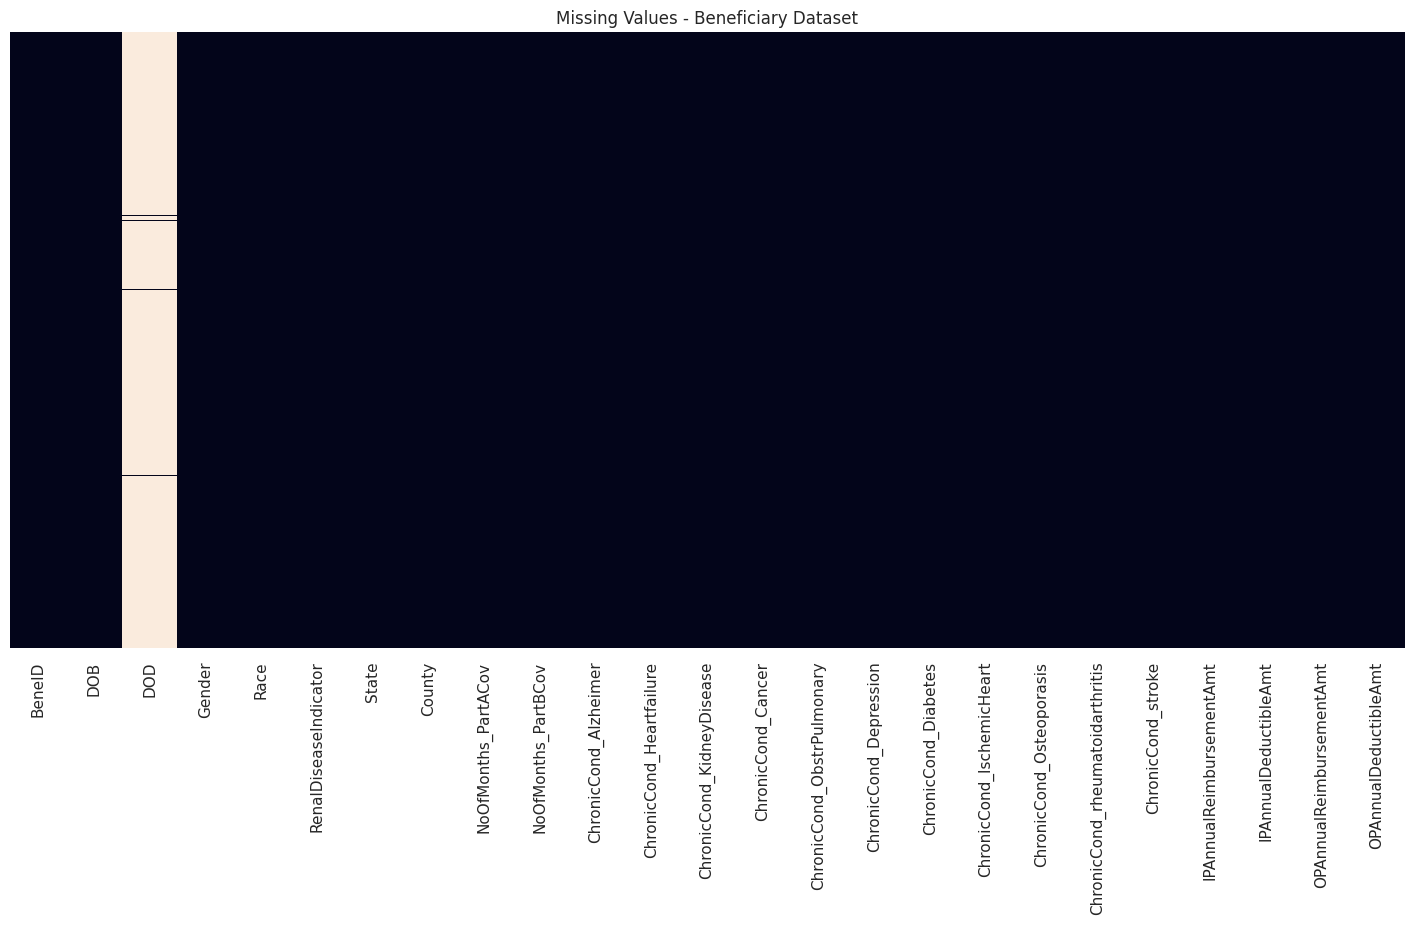

In [13]:
# Visualize Missing Values
plt.figure(figsize=(18,8))

sns.heatmap(
    beneficiary.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values - Beneficiary Dataset")
plt.show()

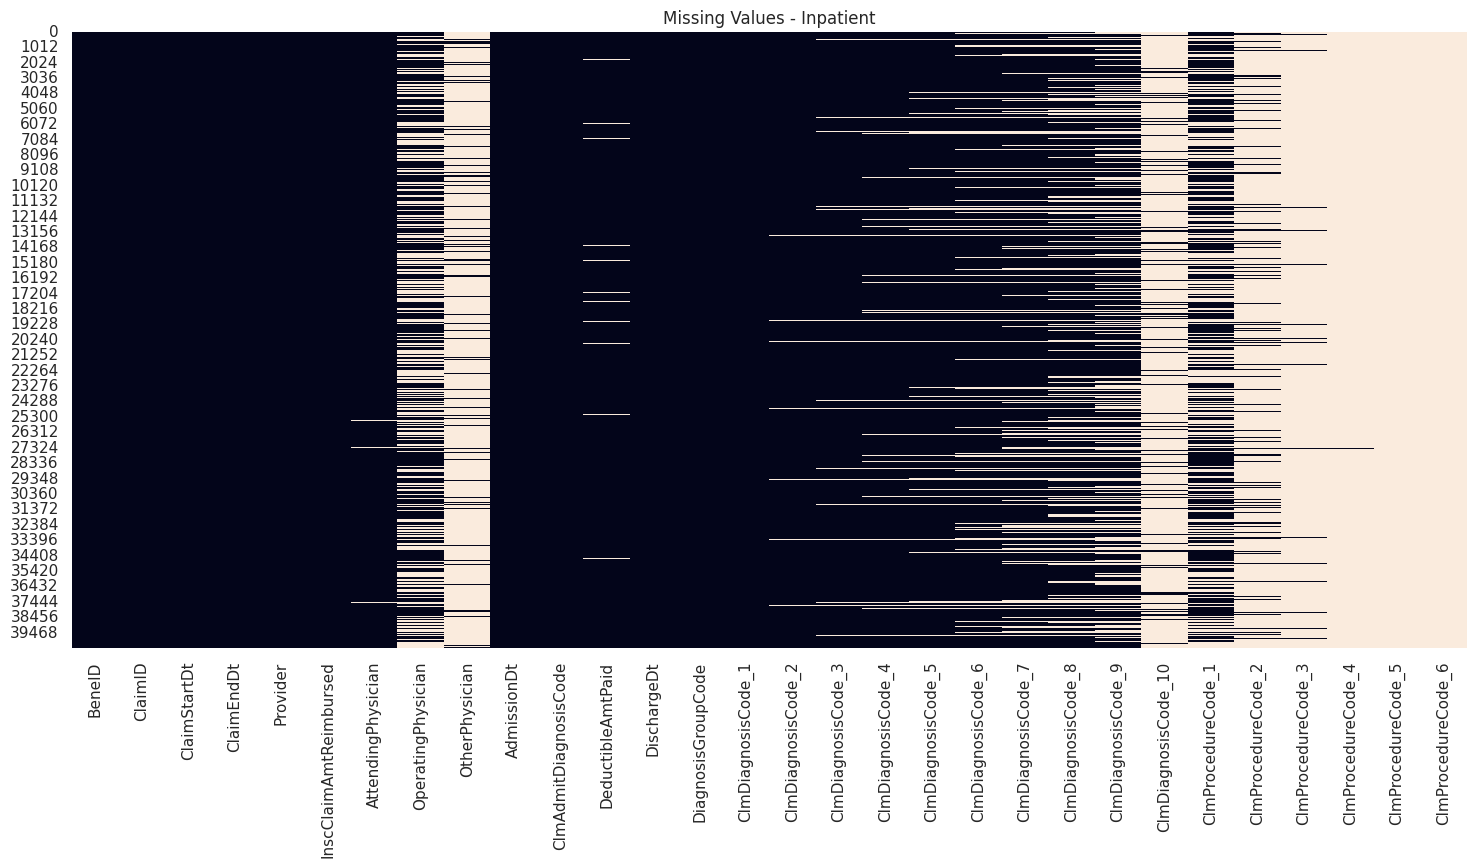

In [14]:
plt.figure(figsize=(18,8))
sns.heatmap(inpatient.isnull(),cbar=False)
plt.title("Missing Values - Inpatient")
plt.show()

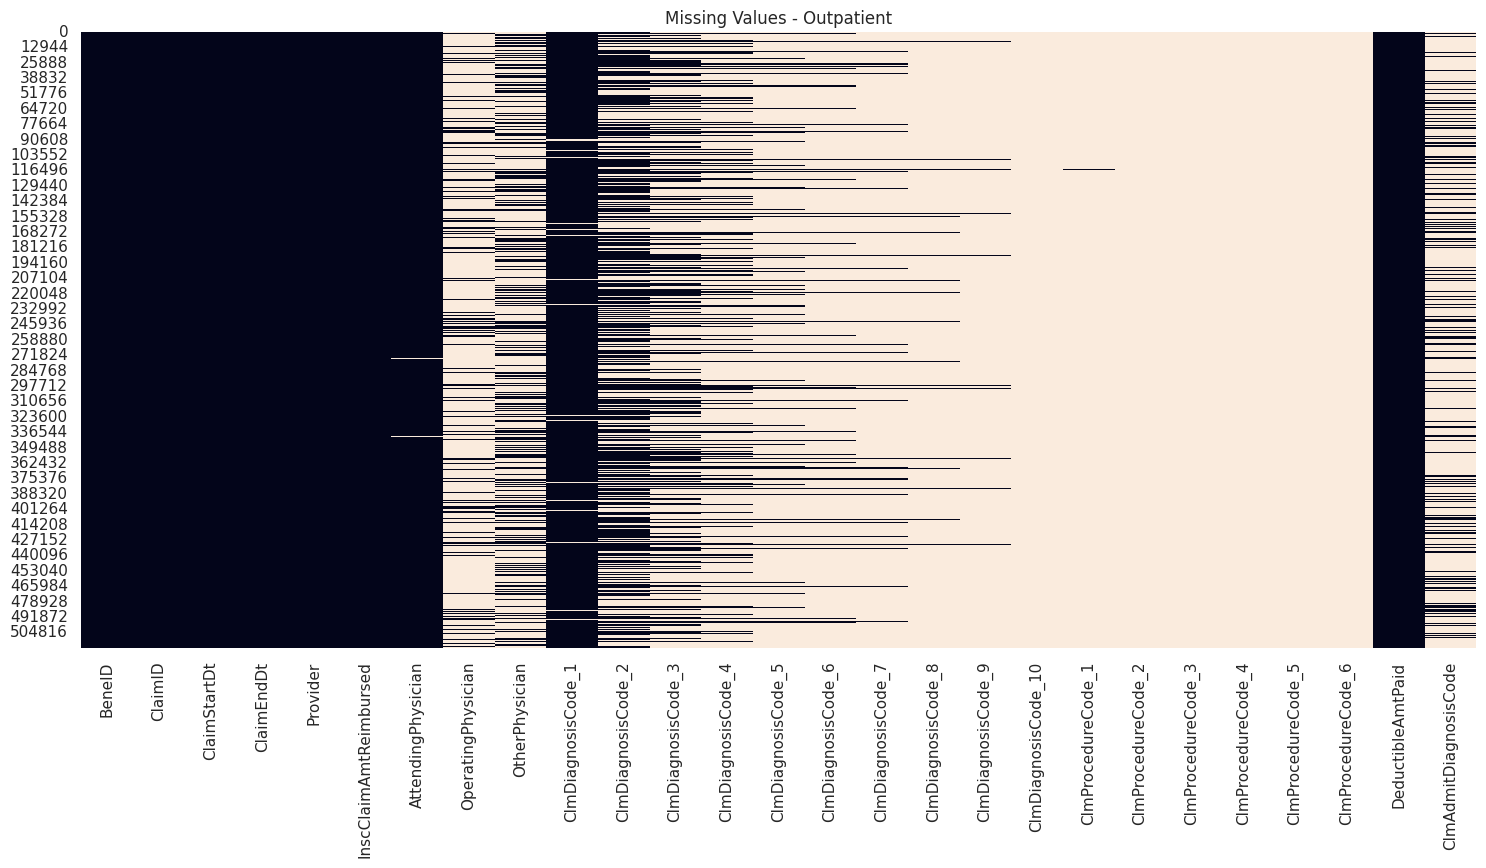

In [15]:
plt.figure(figsize=(18,8))
sns.heatmap(outpatient.isnull(),cbar=False)
plt.title("Missing Values - Outpatient")
plt.show()

In [16]:
# Convert Date Columns
date_columns = [

'ClaimStartDt',
'ClaimEndDt',
'AdmissionDt',
'DischargeDt',
'DOB',
'DOD'
]

for col in date_columns:

    if col in beneficiary.columns:
        beneficiary[col]=pd.to_datetime(
            beneficiary[col],
            errors='coerce'
        )

    if col in inpatient.columns:
        inpatient[col]=pd.to_datetime(
            inpatient[col],
            errors='coerce'
        )

    if col in outpatient.columns:
        outpatient[col]=pd.to_datetime(
            outpatient[col],
            errors='coerce'
        )

    if col in unseen_beneficiary.columns:
        unseen_beneficiary[col]=pd.to_datetime(
            unseen_beneficiary[col],
            errors='coerce'
        )

    if col in unseen_inpatient.columns:
        unseen_inpatient[col]=pd.to_datetime(
            unseen_inpatient[col],
            errors='coerce'
        )

    if col in unseen_outpatient.columns:
        unseen_outpatient[col]=pd.to_datetime(
            unseen_outpatient[col],
            errors='coerce'
        )

print("Date Conversion Completed")

Date Conversion Completed


In [17]:
# Check Data Types
for name, df in datasets.items():

    print(name)

    display(df.dtypes)

    print("="*60)

Train


,0
Provider,object
PotentialFraud,object


Beneficiary


,0
BeneID,object
DOB,datetime64[ns]
DOD,datetime64[ns]
Gender,int64
Race,int64
RenalDiseaseIndicator,object
State,int64
County,int64
NoOfMonths_PartACov,int64
NoOfMonths_PartBCov,int64


Inpatient


...

,0
BeneID,object
DOB,datetime64[ns]
DOD,datetime64[ns]
Gender,int64
Race,int64
RenalDiseaseIndicator,object
State,int64
County,int64
NoOfMonths_PartACov,int64
NoOfMonths_PartBCov,int64


Unseen Inpatient


,0
BeneID,object
ClaimID,object
ClaimStartDt,datetime64[ns]
ClaimEndDt,datetime64[ns]
Provider,object
InscClaimAmtReimbursed,int64
AttendingPhysician,object
OperatingPhysician,object
OtherPhysician,object
AdmissionDt,datetime64[ns]


Unseen Outpatient


,0
BeneID,object
ClaimID,object
ClaimStartDt,datetime64[ns]
ClaimEndDt,datetime64[ns]
Provider,object
InscClaimAmtReimbursed,int64
AttendingPhysician,object
OperatingPhysician,object
OtherPhysician,object
ClmDiagnosisCode_1,object


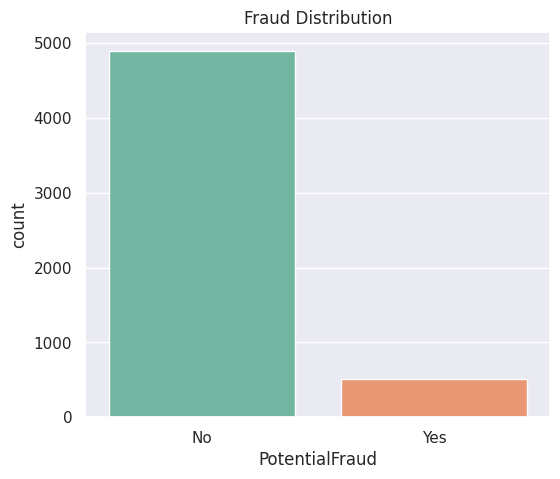

In [18]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='PotentialFraud',
    data=train,
    palette='Set2'
)

plt.title("Fraud Distribution")

plt.show()

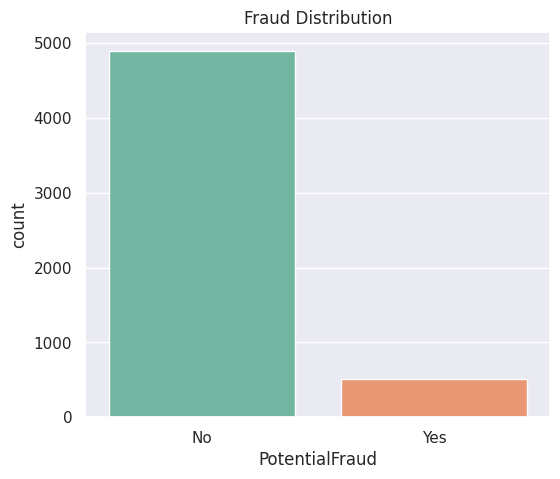

In [19]:
#Fraud Distribution
plt.figure(figsize=(6,5))

sns.countplot(
    x='PotentialFraud',
    data=train,
    palette='Set2'
)

plt.title("Fraud Distribution")

plt.show()

In [20]:
#Percentage of Fraud
fraud_percent = (
train.PotentialFraud
.value_counts(normalize=True)*100
)

display(fraud_percent)

,proportion
PotentialFraud,
No,90.65
Yes,9.35


In [21]:
# Unique Providers

print("Training Providers :",train.Provider.nunique())

print("Beneficiaries :",beneficiary.BeneID.nunique())

print("Inpatient Providers :",inpatient.Provider.nunique())

print("Outpatient Providers :",outpatient.Provider.nunique())

Training Providers : 5410
Beneficiaries : 138556
Inpatient Providers : 2092
Outpatient Providers : 5012


In [22]:
# Initial Sanity Check
print("Common Providers")

len(
set(train.Provider)
&
set(outpatient.Provider)
)

Common Providers


5012

In [23]:
print("Common Providers")

len(
set(train.Provider)
&
set(inpatient.Provider)
)

Common Providers


2092

In [24]:
# Add Claim Type
inpatient['ClaimType']="Inpatient"

outpatient['ClaimType']="Outpatient"

unseen_inpatient['ClaimType']="Inpatient"

unseen_outpatient['ClaimType']="Outpatient"

In [25]:
# Merge Claim Tables

all_claims = pd.concat(
    [inpatient,outpatient],
    ignore_index=True
)

unseen_claims = pd.concat(
    [unseen_inpatient,unseen_outpatient],
    ignore_index=True
)

print(all_claims.shape)

print(unseen_claims.shape)

(558211, 31)
(135392, 31)


In [26]:
# Merge Beneficiary Information

all_claims = all_claims.merge(
    beneficiary,
    on='BeneID',
    how='left'
)

unseen_claims = unseen_claims.merge(
    unseen_beneficiary,
    on='BeneID',
    how='left'
)

print(all_claims.shape)

print(unseen_claims.shape)

(558211, 55)
(135392, 55)


In [27]:
# Verify Merge Integrity

print("Missing Beneficiaries After Merge")

print(
all_claims['BeneID'].isna().sum()
)

print(
unseen_claims['BeneID'].isna().sum()
)

Missing Beneficiaries After Merge
0
0


In [28]:
# Save Intermediate Files (Optional)

all_claims.to_csv(
    "all_claims.csv",
    index=False
)

unseen_claims.to_csv(
    "unseen_claims.csv",
    index=False
)

print("Intermediate datasets saved.")

Intermediate datasets saved.


In [29]:
## EDA

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1)

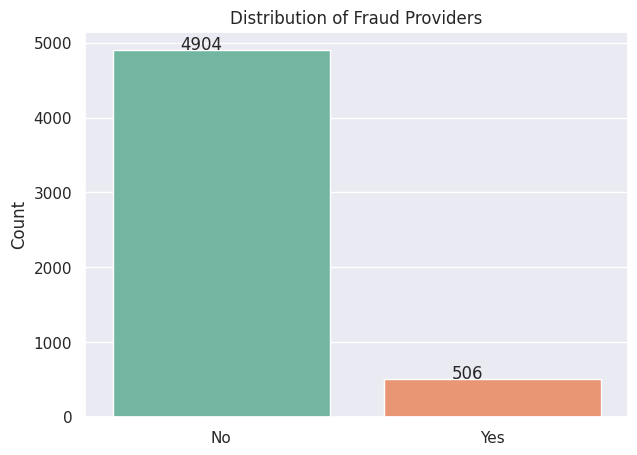

In [31]:
# Fraud Distribution
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=train,
    x="PotentialFraud",
    palette="Set2"
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+0.25,p.get_height()+5)
    )

plt.title("Distribution of Fraud Providers")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

In [32]:
# Fraud Percentage

fraud_percent = (
train.PotentialFraud
.value_counts(normalize=True)
.mul(100)
.round(2)
)

display(fraud_percent)

,proportion
PotentialFraud,
No,90.65
Yes,9.35


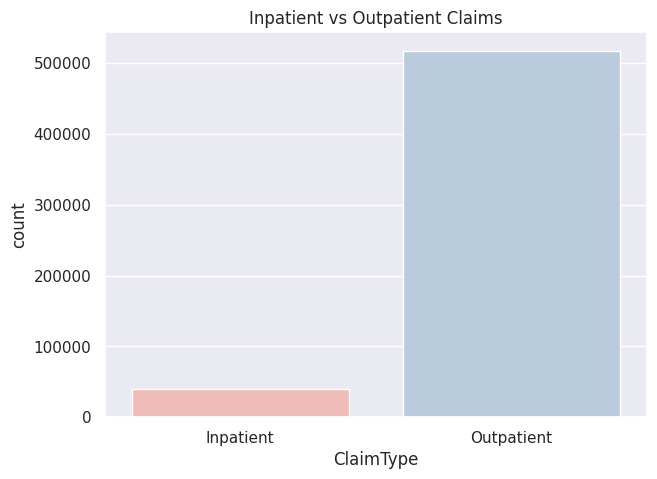

In [33]:
# Claim Type Distribution

plt.figure(figsize=(7,5))

sns.countplot(
    data=all_claims,
    x="ClaimType",
    palette="Pastel1"
)

plt.title("Inpatient vs Outpatient Claims")

plt.show()

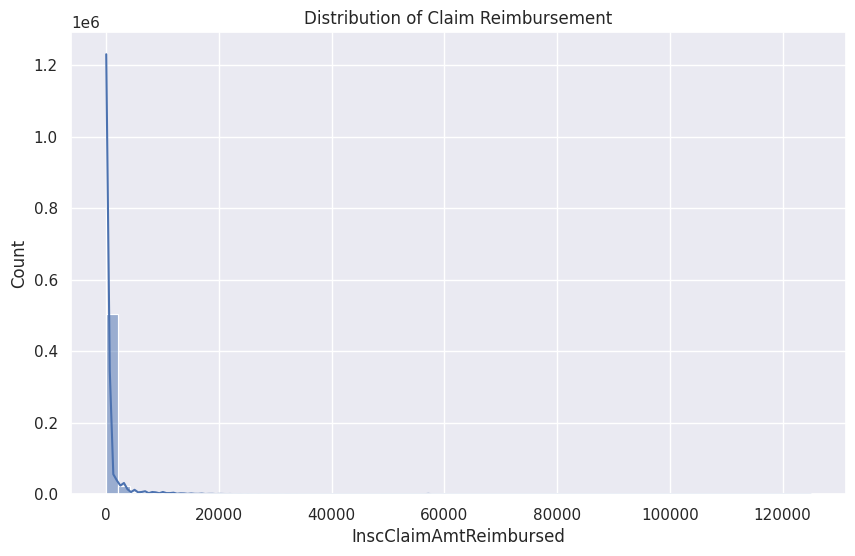

In [34]:
# Reimbursement Amount Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    all_claims["InscClaimAmtReimbursed"],
    bins=60,
    kde=True
)

plt.title("Distribution of Claim Reimbursement")

plt.show()

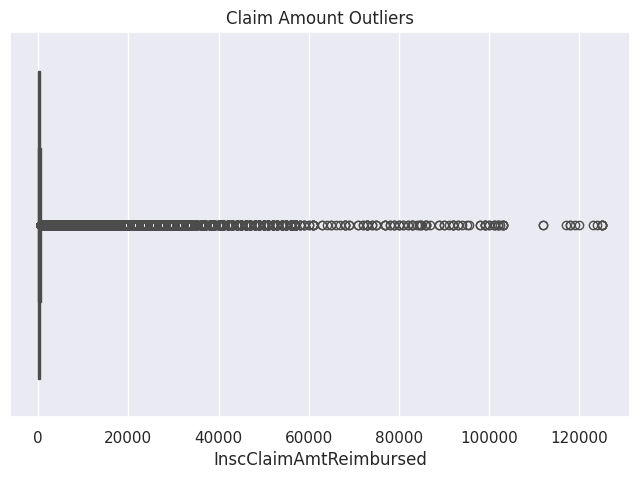

In [35]:
# Boxplot for Claim Amount
plt.figure(figsize=(8,5))

sns.boxplot(
    x=all_claims["InscClaimAmtReimbursed"]
)

plt.title("Claim Amount Outliers")

plt.show()

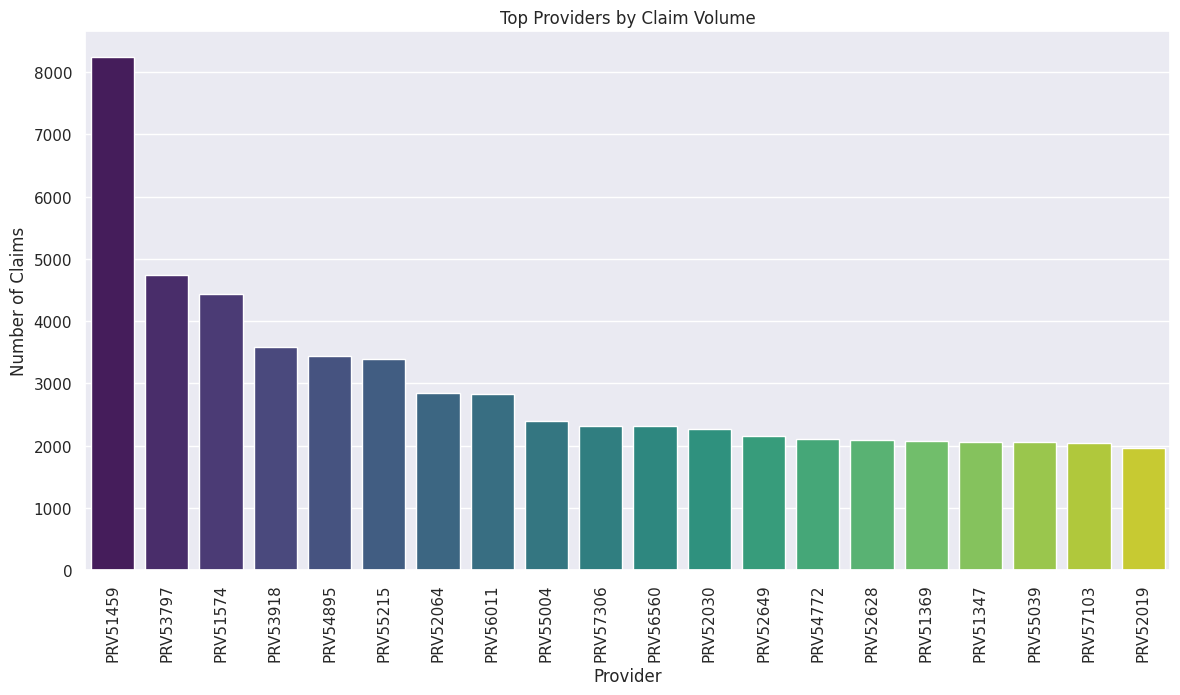

In [36]:
# Top 20 Providers by Claim Count
provider_claims = (
all_claims.Provider
.value_counts()
.head(20)
)

plt.figure(figsize=(14,7))

sns.barplot(
    x=provider_claims.index,
    y=provider_claims.values,
    palette="viridis"
)

plt.xticks(rotation=90)

plt.ylabel("Number of Claims")

plt.title("Top Providers by Claim Volume")

plt.show()

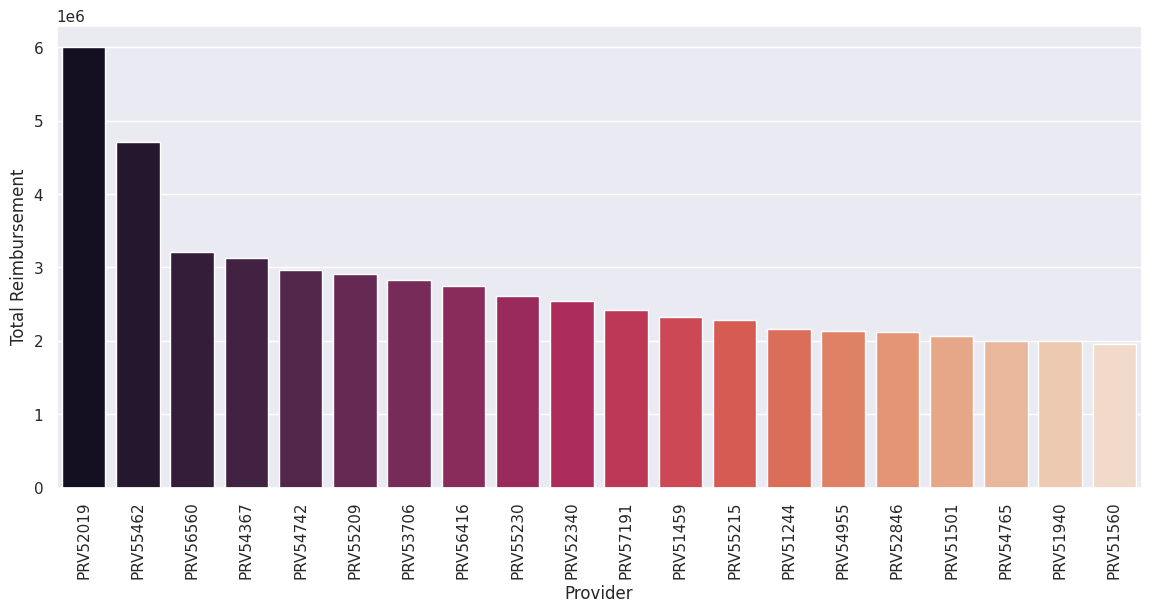

In [37]:
# Top Providers by Total Reimbursement
top_amount = (
all_claims.groupby("Provider")
["InscClaimAmtReimbursed"]
.sum()
.sort_values(ascending=False)
.head(20)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_amount.index,
    y=top_amount.values,
    palette="rocket"
)

plt.xticks(rotation=90)

plt.ylabel("Total Reimbursement")

plt.show()

In [38]:
# Age Distribution
# First Create Age
today = pd.Timestamp.today()

beneficiary["Age"] = (
(today-beneficiary["DOB"])
.dt.days/365
).astype(int)

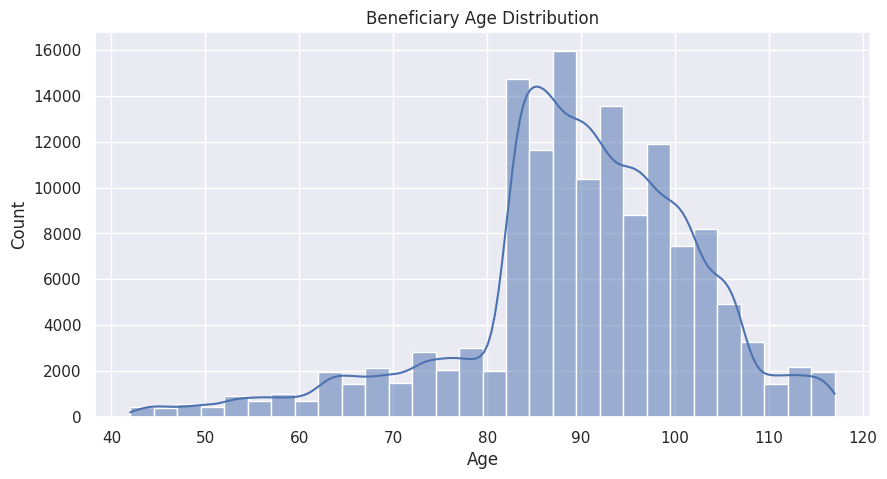

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(
    beneficiary["Age"],
    bins=30,
    kde=True
)

plt.title("Beneficiary Age Distribution")

plt.show()

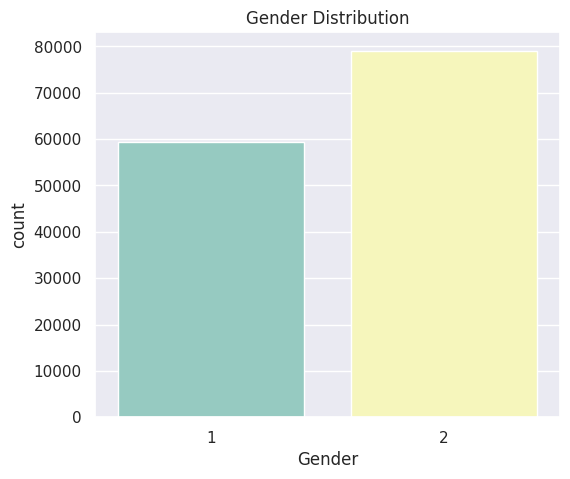

In [40]:
#Gender Distribution
plt.figure(figsize=(6,5))

sns.countplot(
    data=beneficiary,
    x="Gender",
    palette="Set3"
)

plt.title("Gender Distribution")

plt.show()

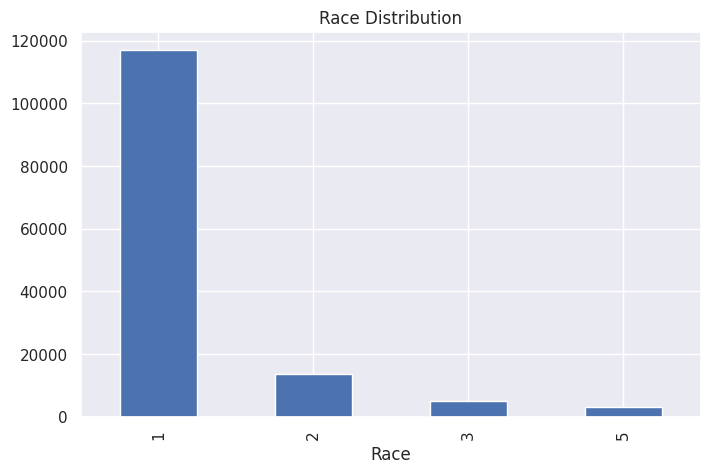

In [41]:
# Race Distribution
plt.figure(figsize=(8,5))

beneficiary.Race.value_counts().plot(
    kind="bar"
)

plt.title("Race Distribution")

plt.show()

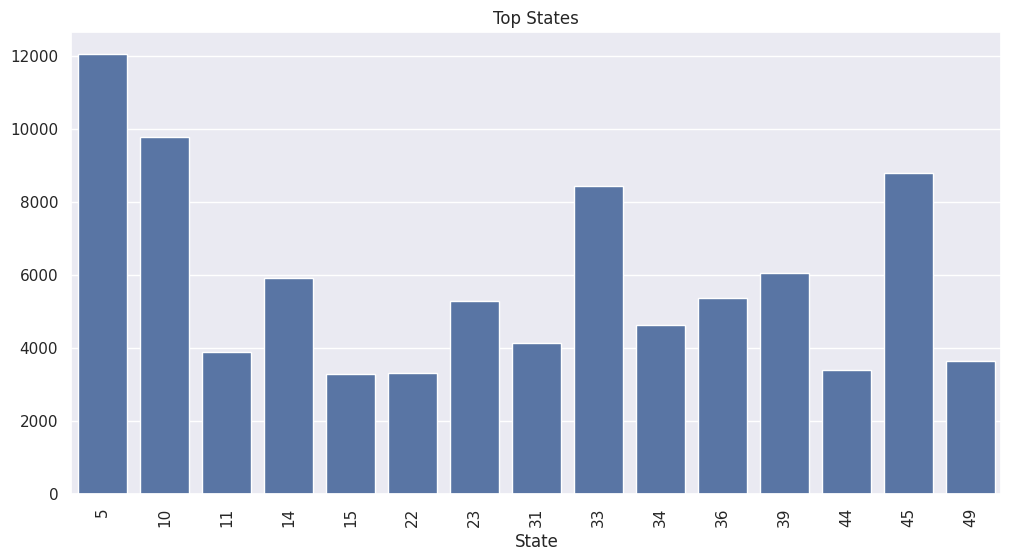

In [42]:
# State- wise Beneficiaries
top_states = (
beneficiary.State
.value_counts()
.head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.xticks(rotation=90)

plt.title("Top States")

plt.show()

In [43]:
# Chronic Conditions
chronic_cols = [

col for col in beneficiary.columns

if "ChronicCond" in col

]

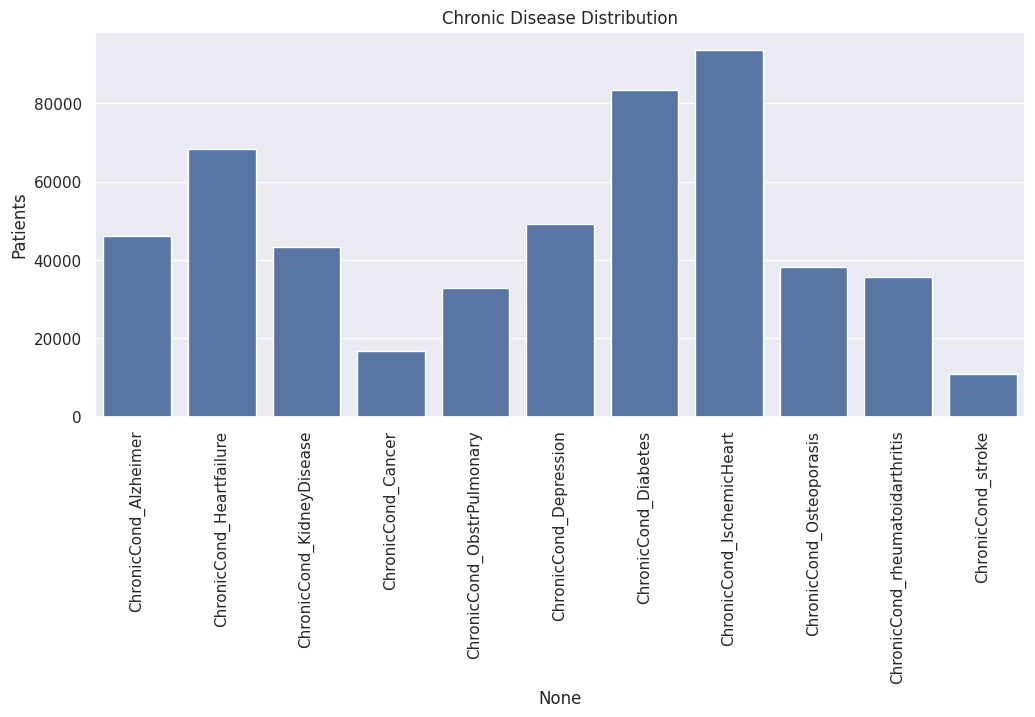

In [44]:
chronic_sum = beneficiary[chronic_cols].eq(1).sum()

plt.figure(figsize=(12,5))

sns.barplot(
    x=chronic_sum.index,
    y=chronic_sum.values
)

plt.xticks(rotation=90)

plt.ylabel("Patients")

plt.title("Chronic Disease Distribution")

plt.show()

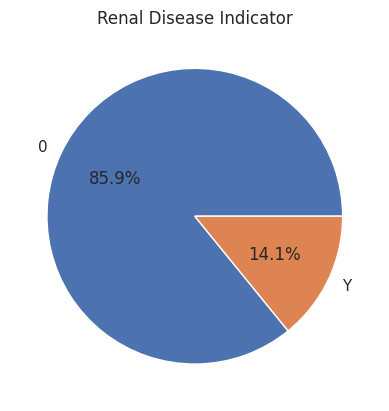

In [45]:
# Renal Disease
beneficiary["RenalDiseaseIndicator"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Renal Disease Indicator")

plt.show()

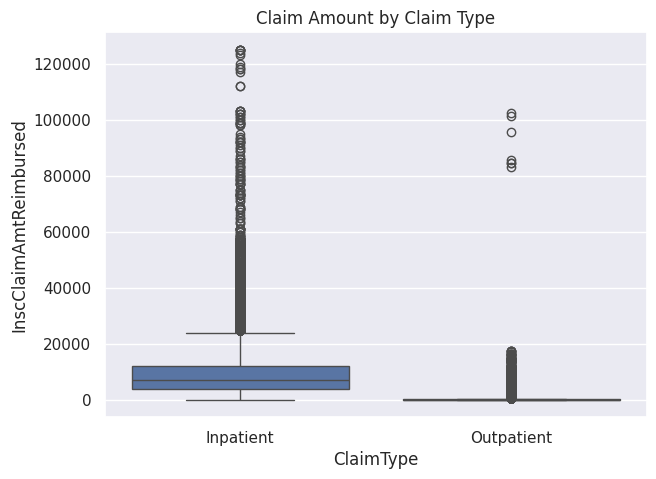

In [46]:
# Claim Amount by Claim Type
plt.figure(figsize=(7,5))

sns.boxplot(
    data=all_claims,
    x="ClaimType",
    y="InscClaimAmtReimbursed"
)

plt.title("Claim Amount by Claim Type")

plt.show()

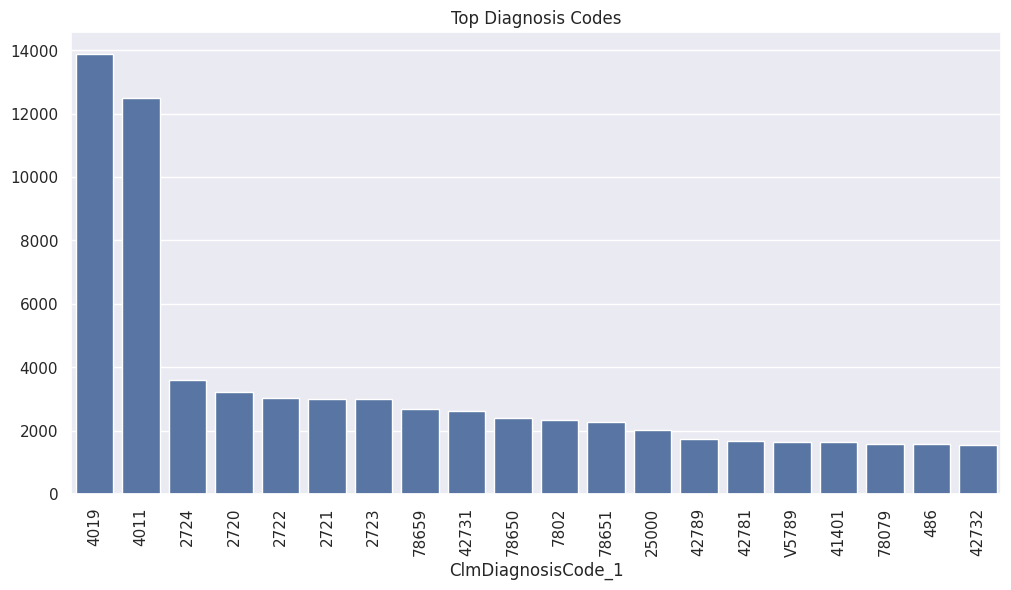

In [47]:
# Diagnosis Code Frequency
diag = (
all_claims["ClmDiagnosisCode_1"]
.value_counts()
.head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
x=diag.index,
y=diag.values
)

plt.xticks(rotation=90)

plt.title("Top Diagnosis Codes")

plt.show()

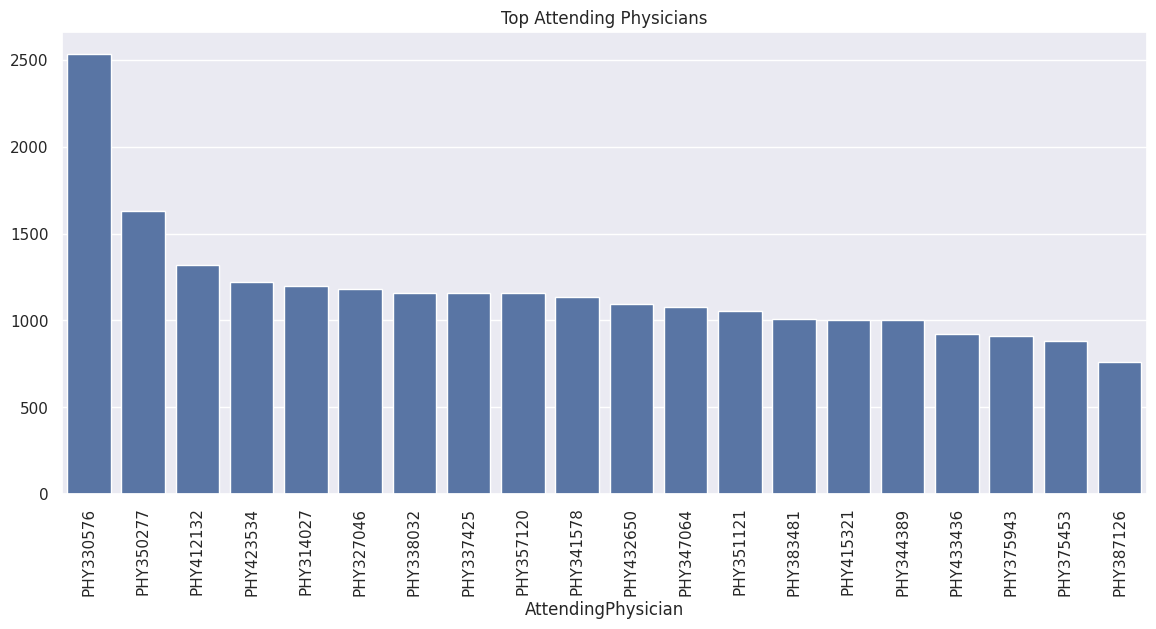

In [48]:
# Top Attending Physicians
top_doc = (
all_claims.AttendingPhysician
.value_counts()
.head(20)
)

plt.figure(figsize=(14,6))

sns.barplot(
x=top_doc.index,
y=top_doc.values
)

plt.xticks(rotation=90)

plt.title("Top Attending Physicians")

plt.show()

In [49]:
# Hospital Stay Distribution
all_claims["HospitalStay"] = (

all_claims["DischargeDt"]

-

all_claims["AdmissionDt"]

).dt.days

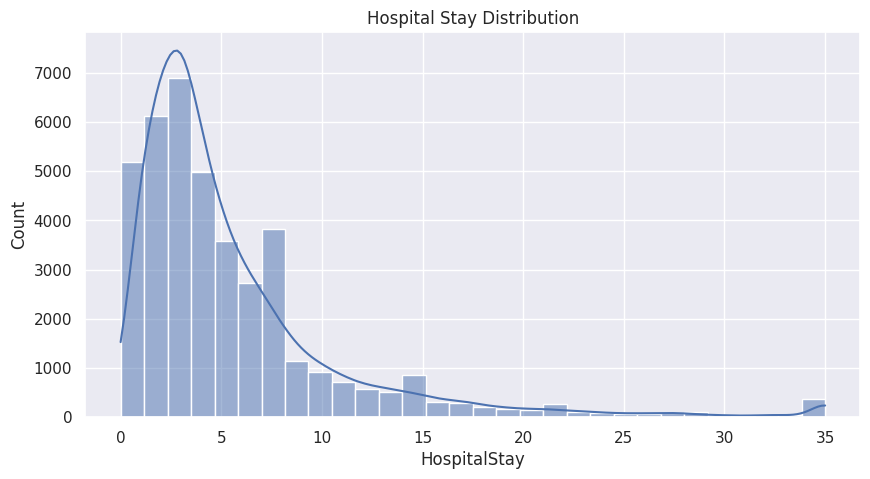

In [50]:
plt.figure(figsize=(10,5))

sns.histplot(
all_claims["HospitalStay"].dropna(),
bins=30,
kde=True
)

plt.title("Hospital Stay Distribution")

plt.show()

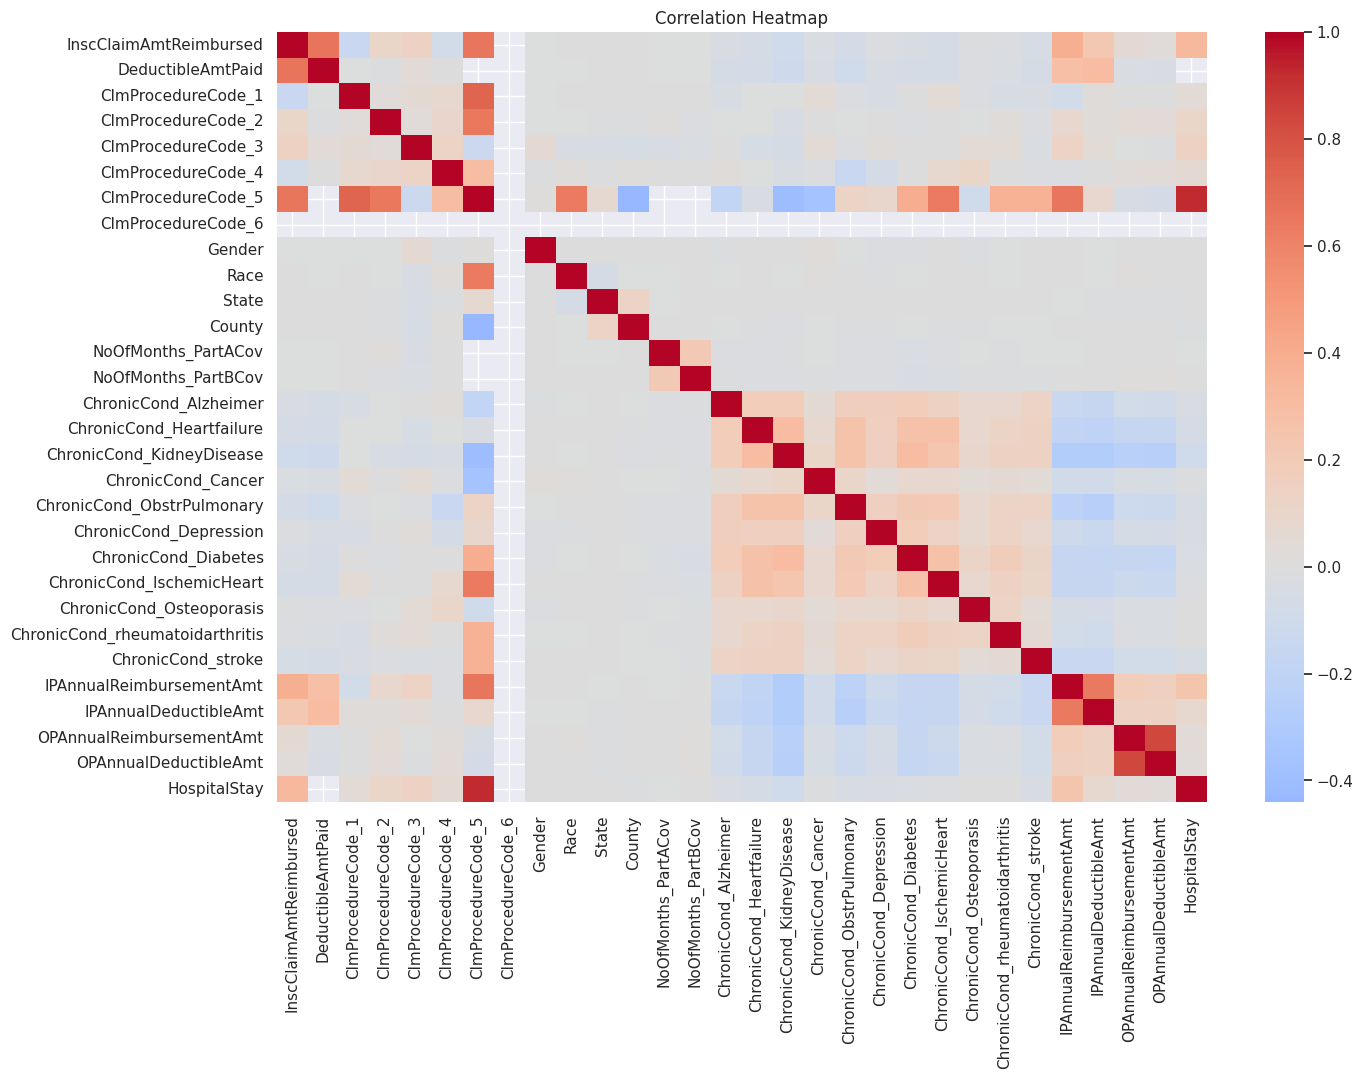

In [51]:
# Correlation Heatmap (Numeric Features)
numeric = all_claims.select_dtypes(include=np.number)

plt.figure(figsize=(15,10))

sns.heatmap(
numeric.corr(),
cmap="coolwarm",
center=0
)

plt.title("Correlation Heatmap")

plt.show()

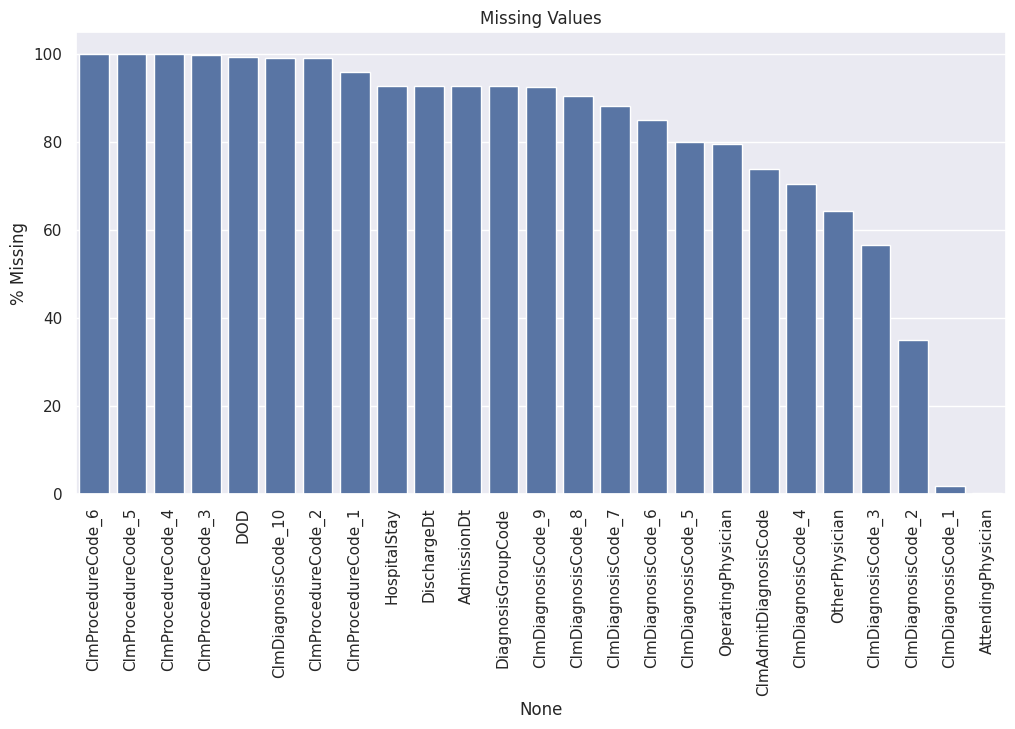

In [52]:
# Missing Value Percentage
missing = (
all_claims.isnull()
.mean()
.sort_values(ascending=False)
.head(25)
*100
)

plt.figure(figsize=(12,6))

sns.barplot(
x=missing.index,
y=missing.values
)

plt.xticks(rotation=90)

plt.ylabel("% Missing")

plt.title("Missing Values")

plt.show()

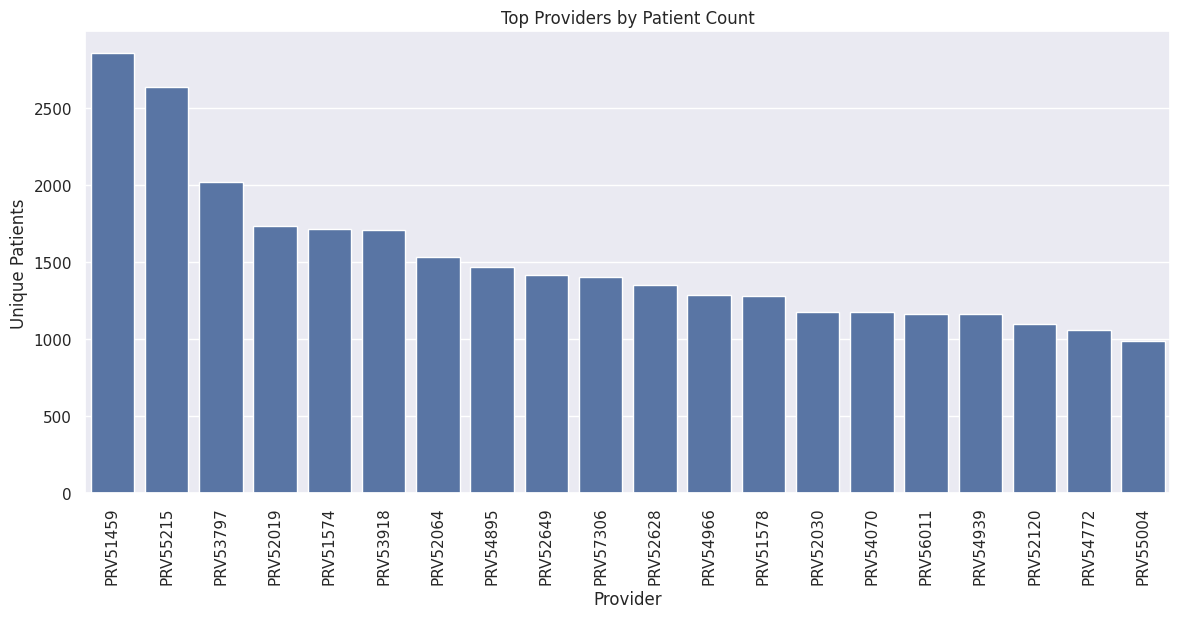

In [53]:
# Provider-wise Unique Beneficiaries
provider_patient = (

all_claims.groupby("Provider")

["BeneID"]

.nunique()

.sort_values(ascending=False)

.head(20)

)

plt.figure(figsize=(14,6))

sns.barplot(
x=provider_patient.index,
y=provider_patient.values
)

plt.xticks(rotation=90)

plt.ylabel("Unique Patients")

plt.title("Top Providers by Patient Count")

plt.show()

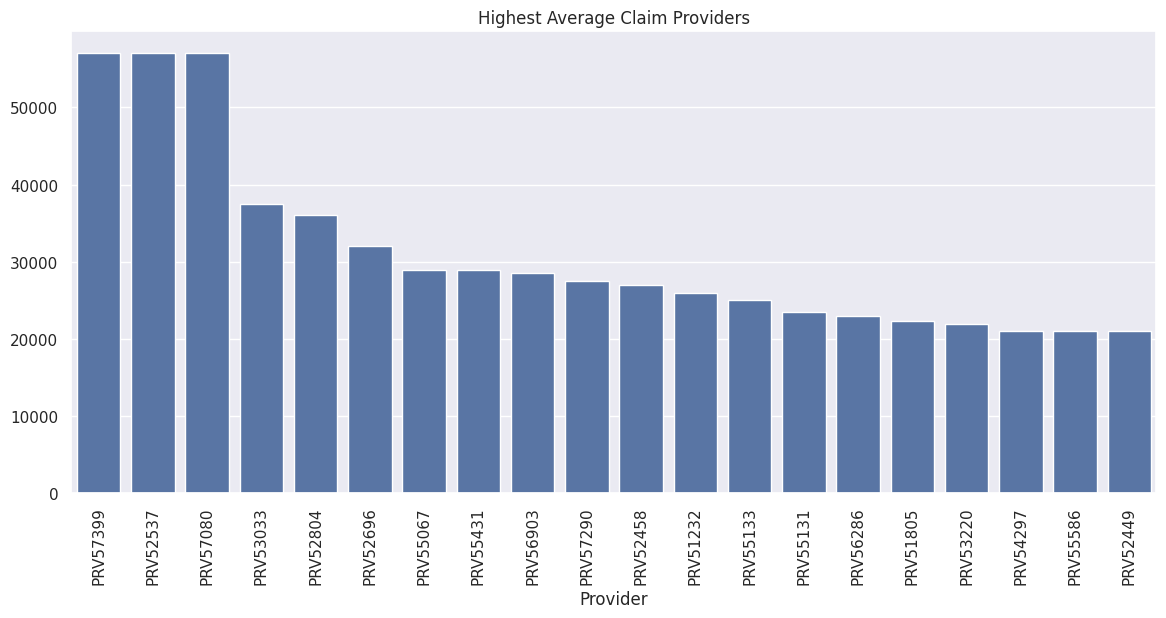

In [54]:
# Provider-wise Average Claim
avg_claim = (

all_claims.groupby("Provider")

["InscClaimAmtReimbursed"]

.mean()

.sort_values(ascending=False)

.head(20)

)

plt.figure(figsize=(14,6))

sns.barplot(
x=avg_claim.index,
y=avg_claim.values
)

plt.xticks(rotation=90)

plt.title("Highest Average Claim Providers")

plt.show()

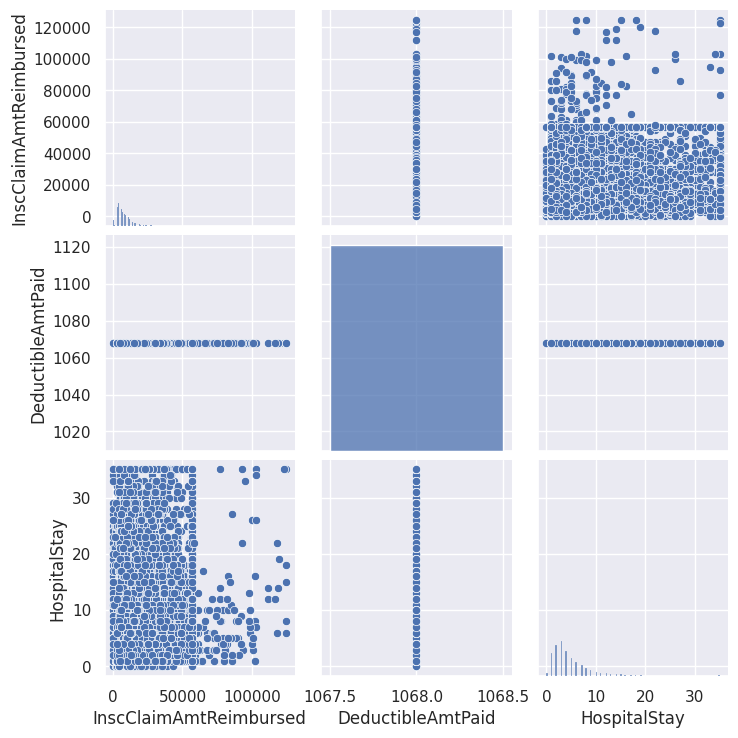

In [55]:
# Pairplot (Selected Variables)

cols = [

"InscClaimAmtReimbursed",

"DeductibleAmtPaid",

"HospitalStay"

]

sns.pairplot(

all_claims[cols].dropna()

)

plt.show()

In [56]:
# Summary Statistics for Claims
claim_summary = (

all_claims

.groupby("ClaimType")

["InscClaimAmtReimbursed"]

.describe()

)

display(claim_summary)

,count,mean,std,min,25%,50%,75%,max
ClaimType,,,,,,,,
Inpatient,40474.00,10087.88,10303.10,0.00,4000.00,7000.00,12000.00,125000.00
Outpatient,517737.00,286.33,694.03,0.00,40.00,80.00,200.00,102500.00


Key Findings

The fraud dataset is imbalanced, so techniques like SMOTE or class weighting will be needed during modeling.
Outpatient claims make up a larger share of the dataset than inpatient claims.
Claim reimbursement amounts are highly right-skewed with several extreme outliers.
A small number of providers account for a disproportionately large number of claims and reimbursements.
Beneficiaries are predominantly elderly, which aligns with the Medicare population.
Hospital stay durations vary considerably, suggesting this feature may help distinguish provider behavior.
Several diagnosis and physician identifiers appear repeatedly and may be valuable when aggregated at the provider level.
Missing values are concentrated in specific clinical fields and should be handled appropriately during feature engineering.

In [57]:
# Create Hospital Stay Feature

# ============================================================
# Hospital Stay Length
# ============================================================

all_claims["HospitalStay"] = (
    all_claims["DischargeDt"] -
    all_claims["AdmissionDt"]
).dt.days

unseen_claims["HospitalStay"] = (
    unseen_claims["DischargeDt"] -
    unseen_claims["AdmissionDt"]
).dt.days

all_claims["HospitalStay"] = all_claims["HospitalStay"].fillna(0)

unseen_claims["HospitalStay"] = unseen_claims["HospitalStay"].fillna(0)

In [58]:
# Create Beneficiary Age
today = pd.Timestamp.today()

all_claims["Age"] = (
    (today-all_claims["DOB"]).dt.days/365
).astype(int)

unseen_claims["Age"] = (
    (today-unseen_claims["DOB"]).dt.days/365
).astype(int)

In [59]:
# Number of Chronic Diseases
chronic_cols = [

col for col in all_claims.columns

if "ChronicCond" in col

]

all_claims["TotalChronicDisease"] = (
all_claims[chronic_cols]==1
).sum(axis=1)

unseen_claims["TotalChronicDisease"] = (
unseen_claims[chronic_cols]==1
).sum(axis=1)

In [60]:
# Renal Disease Flag
all_claims["RenalDisease"] = np.where(
all_claims["RenalDiseaseIndicator"]=="Y",
1,
0
)

unseen_claims["RenalDisease"] = np.where(
unseen_claims["RenalDiseaseIndicator"]=="Y",
1,
0
)

In [61]:
# Claim Count
provider_features = pd.DataFrame()

provider_features["TotalClaims"] = (

all_claims

.groupby("Provider")

.size()

)

In [62]:
# Total Reimbursement
provider_features["TotalReimbursement"] = (

all_claims

.groupby("Provider")

["InscClaimAmtReimbursed"]

.sum()

)

In [63]:
# Average Claim
provider_features["AverageClaim"] = (

all_claims

.groupby("Provider")

["InscClaimAmtReimbursed"]

.mean()

)

In [64]:
# Maximum Claim
provider_features["MaximumClaim"] = (

all_claims

.groupby("Provider")

["InscClaimAmtReimbursed"]

.max()

)

In [65]:
# Minimum Claim
provider_features["MinimumClaim"] = (

all_claims

.groupby("Provider")

["InscClaimAmtReimbursed"]

.min()

)

In [66]:
# Median Claim
provider_features["MedianClaim"] = (

all_claims

.groupby("Provider")

["InscClaimAmtReimbursed"]

.median()

)

In [67]:
# Claim Standard Deviation
provider_features["ClaimSTD"] = (

all_claims

.groupby("Provider")

["InscClaimAmtReimbursed"]

.std()

)

In [68]:
# Total Deductible
provider_features["TotalDeductible"] = (

all_claims

.groupby("Provider")

["DeductibleAmtPaid"]

.sum()

)

In [69]:
# Average Deductible
provider_features["AverageDeductible"] = (

all_claims

.groupby("Provider")

["DeductibleAmtPaid"]

.mean()

)

In [70]:
# Inpatient Count
provider_features["InpatientClaims"] = (

all_claims

[all_claims["ClaimType"]=="Inpatient"]

.groupby("Provider")

.size()

)

In [71]:
# Outpatient Count
provider_features["OutpatientClaims"] = (

all_claims

[all_claims["ClaimType"]=="Outpatient"]

.groupby("Provider")

.size()

)

In [72]:
# Inpatient Ratio
provider_features["InpatientRatio"] = (

provider_features["InpatientClaims"]/

provider_features["TotalClaims"]

)

In [73]:
# Outpatient Ratio
provider_features["OutpatientRatio"] = (

provider_features["OutpatientClaims"]/

provider_features["TotalClaims"]

)

In [74]:
# Unique Beneficiaries
provider_features["UniqueBeneficiaries"] = (

all_claims

.groupby("Provider")

["BeneID"]

.nunique()

)

In [75]:
# Repeat Beneficiary Ratio
provider_features["RepeatBeneficiaryRatio"] = (

provider_features["TotalClaims"]/

provider_features["UniqueBeneficiaries"]

)

In [76]:
# Average Age
provider_features["AverageAge"] = (

all_claims

.groupby("Provider")

["Age"]

.mean()

)

In [77]:
# Maximum Age
provider_features["MaximumAge"] = (

all_claims

.groupby("Provider")

["Age"]

.max()

)

In [78]:
# Chronic Disease Average
provider_features["AverageChronicDisease"] = (

all_claims

.groupby("Provider")

["TotalChronicDisease"]

.mean()

)

In [79]:
# Renal Disease Percentage
provider_features["RenalDiseaseRate"] = (

all_claims

.groupby("Provider")

["RenalDisease"]

.mean()

)

In [80]:
# Average Hospital Stay
provider_features["AverageStay"] = (

all_claims

.groupby("Provider")

["HospitalStay"]

.mean()

)

In [81]:
# Maximum Hospital Stay
provider_features["MaximumStay"] = (

all_claims

.groupby("Provider")

["HospitalStay"]

.max()

)

In [82]:
# Total Hospital Stay
provider_features["TotalStay"] = (

all_claims

.groupby("Provider")

["HospitalStay"]

.sum()

)

In [83]:
# Physician Diversity
provider_features["UniqueAttendingPhysician"] = (

all_claims

.groupby("Provider")

["AttendingPhysician"]

.nunique()

)

provider_features["UniqueOperatingPhysician"] = (

all_claims

.groupby("Provider")

["OperatingPhysician"]

.nunique()

)

provider_features["UniqueOtherPhysician"] = (

all_claims

.groupby("Provider")

["OtherPhysician"]

.nunique()

)

In [84]:
# Diagnosis Diversity
diagnosis_cols = [

col for col in all_claims.columns

if "ClmDiagnosisCode" in col
]

provider_features["DiagnosisVariety"] = (

all_claims

.groupby("Provider")[diagnosis_cols]

.nunique()

.sum(axis=1)

)

In [85]:
# Procedure Diversity
procedure_cols = [

col for col in all_claims.columns

if "ClmProcedureCode" in col
]

provider_features["ProcedureVariety"] = (

all_claims

.groupby("Provider")[procedure_cols]

.nunique()

.sum(axis=1)

)

In [86]:
# Gender Diversity
provider_features["UniqueGender"] = (

all_claims

.groupby("Provider")

["Gender"]

.nunique()

)

In [87]:
# Race Diversity
provider_features["UniqueRace"] = (

all_claims

.groupby("Provider")

["Race"]

.nunique()

)

In [88]:
# State Diversity
provider_features["UniqueState"] = (

all_claims

.groupby("Provider")

["State"]

.nunique()

)

In [89]:
# County Diversity
provider_features["UniqueCounty"] = (

all_claims

.groupby("Provider")

["County"]

.nunique()

)

In [90]:
# Claim Amount per Beneficiary
provider_features["ClaimPerBeneficiary"] = (

provider_features["TotalReimbursement"]/

provider_features["UniqueBeneficiaries"]

)

In [91]:
# Average Claims per Physician
provider_features["ClaimsPerDoctor"] = (

provider_features["TotalClaims"]/

provider_features["UniqueAttendingPhysician"]

)

In [92]:
# Fill Missing Values
provider_features = provider_features.fillna(0)

In [93]:
# Reset Index
provider_features = provider_features.reset_index()

In [94]:
# Merge Fraud Labels
provider_features = provider_features.merge(
    train,
    on="Provider",
    how="left"
)

provider_features.head()

,Provider,TotalClaims,TotalReimbursement,AverageClaim,MaximumClaim,MinimumClaim,MedianClaim,ClaimSTD,TotalDeductible,AverageDeductible,InpatientClaims,OutpatientClaims,InpatientRatio,OutpatientRatio,UniqueBeneficiaries,RepeatBeneficiaryRatio,AverageAge,MaximumAge,AverageChronicDisease,RenalDiseaseRate,AverageStay,MaximumStay,TotalStay,UniqueAttendingPhysician,UniqueOperatingPhysician,UniqueOtherPhysician,DiagnosisVariety,ProcedureVariety,UniqueGender,UniqueRace,UniqueState,UniqueCounty,ClaimPerBeneficiary,ClaimsPerDoctor,PotentialFraud
0,PRV51001,25,104640,4185.60,42000,10,400.00,10796.09,5340.00,213.60,5.00,20.00,0.20,0.80,24,1.04,94.88,114,5.56,0.32,1.00,14.00,25.00,14,5,8,78,3,2,2,1,7,4360.00,1.79,No
1,PRV51003,132,605670,4588.41,57000,0,1750.00,7309.79,66286.00,502.17,62.00,70.00,0.47,0.53,117,1.13,86.09,113,4.55,0.22,2.42,27.00,320.00,44,7,22,559,39,2,3,3,23,5176.67,3.00,Yes
2,PRV51004,149,52170,350.13,3300,0,70.00,689.96,310.00,2.08,0.00,149.00,0.00,1.00,138,1.08,88.28,116,4.34,0.15,0.00,0.00,0.00,38,19,26,332,0,2,3,9,28,378.04,3.92,No
3,PRV51005,1165,280910,241.12,4080,0,70.00,491.56,3700.00,3.18,0.00,1165.00,0.00,1.00,495,2.35,86.58,117,4.34,0.22,0.00,0.00,0.00,6,6,4,1873,0,2,3,4,26,567.49,194.17,Yes
4,PRV51007,72,33710,468.19,10000,0,80.00,1433.77,3264.00,45.33,3.00,69.00,0.04,0.96,58,1.24,85.44,115,4.17,0.15,0.22,7.00,16.00,10,5,7,198,1,2,2,2,6,581.21,7.20,No


In [95]:
# Create Unseen Provider Features
def create_provider_features(df):
    pf = pd.DataFrame(index=df["Provider"].unique())

    grp = df.groupby("Provider")

    pf["TotalClaims"] = grp.size()
    pf["TotalReimbursement"] = grp["InscClaimAmtReimbursed"].sum()
    pf["AverageClaim"] = grp["InscClaimAmtReimbursed"].mean()
    pf["MaximumClaim"] = grp["InscClaimAmtReimbursed"].max()
    pf["MinimumClaim"] = grp["InscClaimAmtReimbursed"].min()
    pf["MedianClaim"] = grp["InscClaimAmtReimbursed"].median()
    pf["ClaimSTD"] = grp["InscClaimAmtReimbursed"].std()

    pf["TotalDeductible"] = grp["DeductibleAmtPaid"].sum()
    pf["AverageDeductible"] = grp["DeductibleAmtPaid"].mean()

    pf["InpatientClaims"] = (
        df[df["ClaimType"]=="Inpatient"]
        .groupby("Provider")
        .size()
    )

    pf["OutpatientClaims"] = (
        df[df["ClaimType"]=="Outpatient"]
        .groupby("Provider")
        .size()
    )

    pf["UniqueBeneficiaries"] = grp["BeneID"].nunique()
    pf["AverageAge"] = grp["Age"].mean()
    pf["AverageStay"] = grp["HospitalStay"].mean()
    pf["AverageChronicDisease"] = grp["TotalChronicDisease"].mean()
    pf["RenalDiseaseRate"] = grp["RenalDisease"].mean()

    pf["UniqueAttendingPhysician"] = grp["AttendingPhysician"].nunique()
    pf["UniqueOperatingPhysician"] = grp["OperatingPhysician"].nunique()
    pf["UniqueOtherPhysician"] = grp["OtherPhysician"].nunique()

    pf["UniqueState"] = grp["State"].nunique()
    pf["UniqueCounty"] = grp["County"].nunique()
    pf["UniqueRace"] = grp["Race"].nunique()
    pf["UniqueGender"] = grp["Gender"].nunique()

    pf["DiagnosisVariety"] = grp[diagnosis_cols].nunique().sum(axis=1)
    pf["ProcedureVariety"] = grp[procedure_cols].nunique().sum(axis=1)

    pf = pf.fillna(0).reset_index().rename(columns={"index": "Provider"})

    return pf

In [96]:
unseen_provider_features = create_provider_features(unseen_claims)

print(provider_features.shape)
print(unseen_provider_features.shape)
provider_features.head()

(5410, 35)
(1353, 26)


,Provider,TotalClaims,TotalReimbursement,AverageClaim,MaximumClaim,MinimumClaim,MedianClaim,ClaimSTD,TotalDeductible,AverageDeductible,InpatientClaims,OutpatientClaims,InpatientRatio,OutpatientRatio,UniqueBeneficiaries,RepeatBeneficiaryRatio,AverageAge,MaximumAge,AverageChronicDisease,RenalDiseaseRate,AverageStay,MaximumStay,TotalStay,UniqueAttendingPhysician,UniqueOperatingPhysician,UniqueOtherPhysician,DiagnosisVariety,ProcedureVariety,UniqueGender,UniqueRace,UniqueState,UniqueCounty,ClaimPerBeneficiary,ClaimsPerDoctor,PotentialFraud
0,PRV51001,25,104640,4185.60,42000,10,400.00,10796.09,5340.00,213.60,5.00,20.00,0.20,0.80,24,1.04,94.88,114,5.56,0.32,1.00,14.00,25.00,14,5,8,78,3,2,2,1,7,4360.00,1.79,No
1,PRV51003,132,605670,4588.41,57000,0,1750.00,7309.79,66286.00,502.17,62.00,70.00,0.47,0.53,117,1.13,86.09,113,4.55,0.22,2.42,27.00,320.00,44,7,22,559,39,2,3,3,23,5176.67,3.00,Yes
2,PRV51004,149,52170,350.13,3300,0,70.00,689.96,310.00,2.08,0.00,149.00,0.00,1.00,138,1.08,88.28,116,4.34,0.15,0.00,0.00,0.00,38,19,26,332,0,2,3,9,28,378.04,3.92,No
3,PRV51005,1165,280910,241.12,4080,0,70.00,491.56,3700.00,3.18,0.00,1165.00,0.00,1.00,495,2.35,86.58,117,4.34,0.22,0.00,0.00,0.00,6,6,4,1873,0,2,3,4,26,567.49,194.17,Yes
4,PRV51007,72,33710,468.19,10000,0,80.00,1433.77,3264.00,45.33,3.00,69.00,0.04,0.96,58,1.24,85.44,115,4.17,0.15,0.22,7.00,16.00,10,5,7,198,1,2,2,2,6,581.21,7.20,No


In [97]:
# Save Engineered Features
provider_features.to_csv(
    "provider_features_train.csv",
    index=False
)

unseen_provider_features.to_csv(
    "provider_features_unseen.csv",
    index=False
)

In [98]:
# ============================================================
# Machine Learning Libraries
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

import joblib

In [99]:
# ============================================
# Prepare Features and Target Variable
# ============================================

# Target Variable
y = provider_features["PotentialFraud"].map({
    "No": 0,
    "Yes": 1
})

# Feature Matrix
X = provider_features.drop(
    columns=[
        "Provider",
        "PotentialFraud"
    ]
)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

display(X.head())

X Shape : (5410, 33)
y Shape : (5410,)


,TotalClaims,TotalReimbursement,AverageClaim,MaximumClaim,MinimumClaim,MedianClaim,ClaimSTD,TotalDeductible,AverageDeductible,InpatientClaims,OutpatientClaims,InpatientRatio,OutpatientRatio,UniqueBeneficiaries,RepeatBeneficiaryRatio,AverageAge,MaximumAge,AverageChronicDisease,RenalDiseaseRate,AverageStay,MaximumStay,TotalStay,UniqueAttendingPhysician,UniqueOperatingPhysician,UniqueOtherPhysician,DiagnosisVariety,ProcedureVariety,UniqueGender,UniqueRace,UniqueState,UniqueCounty,ClaimPerBeneficiary,ClaimsPerDoctor
0,25,104640,4185.60,42000,10,400.00,10796.09,5340.00,213.60,5.00,20.00,0.20,0.80,24,1.04,94.88,114,5.56,0.32,1.00,14.00,25.00,14,5,8,78,3,2,2,1,7,4360.00,1.79
1,132,605670,4588.41,57000,0,1750.00,7309.79,66286.00,502.17,62.00,70.00,0.47,0.53,117,1.13,86.09,113,4.55,0.22,2.42,27.00,320.00,44,7,22,559,39,2,3,3,23,5176.67,3.00
2,149,52170,350.13,3300,0,70.00,689.96,310.00,2.08,0.00,149.00,0.00,1.00,138,1.08,88.28,116,4.34,0.15,0.00,0.00,0.00,38,19,26,332,0,2,3,9,28,378.04,3.92
3,1165,280910,241.12,4080,0,70.00,491.56,3700.00,3.18,0.00,1165.00,0.00,1.00,495,2.35,86.58,117,4.34,0.22,0.00,0.00,0.00,6,6,4,1873,0,2,3,4,26,567.49,194.17
4,72,33710,468.19,10000,0,80.00,1433.77,3264.00,45.33,3.00,69.00,0.04,0.96,58,1.24,85.44,115,4.17,0.15,0.22,7.00,16.00,10,5,7,198,1,2,2,2,6,581.21,7.20


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(4328, 33)
(1082, 33)


In [101]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(7846, 33)
PotentialFraud
0    3923
1    3923
Name: count, dtype: int64


In [102]:
# Handle Class Imbalance Using SMOTE
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original:", X_train.shape)

print("After SMOTE:", X_train_smote.shape)

print(y_train_smote.value_counts())

Original: (4328, 33)
After SMOTE: (7846, 33)
PotentialFraud
0    3923
1    3923
Name: count, dtype: int64


In [103]:
# Create Evaluation Function
def evaluate_model(model, X_test, y_test):

    prediction = model.predict(X_test)

    probability = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    auc = roc_auc_score(y_test, probability)

    print("="*60)

    print(type(model).__name__)

    print("="*60)

    print("Accuracy :", accuracy)

    print("Precision :", precision)

    print("Recall :", recall)

    print("F1 Score :", f1)

    print("ROC AUC :", auc)

    print()

    print(classification_report(y_test,prediction))

    cm = confusion_matrix(y_test,prediction)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(type(model).__name__)

    plt.show()

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test
    )

    plt.show()

    return {
        "Model":type(model).__name__,
        "Accuracy":accuracy,
        "Precision":precision,
        "Recall":recall,
        "F1":f1,
        "ROC_AUC":auc
    }

In [104]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.6 MB/s eta 0:00:00


In [105]:
%pip install catboost

In [106]:
from catboost import CatBoostClassifier

In [107]:
# Initialize Models
models = {

"Logistic Regression":

LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    random_state=42
),

"Decision Tree":

DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
),

"Random Forest":

RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
),

"Extra Trees":

ExtraTreesClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
),

"Gradient Boosting":

GradientBoostingClassifier(
    random_state=42
),

"XGBoost":

XGBClassifier(
    random_state=42,
    eval_metric="logloss"
),

"LightGBM":

LGBMClassifier(
    random_state=42
),

"CatBoost":

CatBoostClassifier(
    verbose=0,
    random_state=42
)

}

Logistic Regression
LogisticRegression
Accuracy : 0.8733826247689463
Precision : 0.4158878504672897
Recall : 0.8811881188118812
F1 Score : 0.5650793650793651
ROC AUC : 0.9479617686539297

              precision    recall  f1-score   support

           0       0.99      0.87      0.93       981
           1       0.42      0.88      0.57       101

    accuracy                           0.87      1082
   macro avg       0.70      0.88      0.75      1082
weighted avg       0.93      0.87      0.89      1082



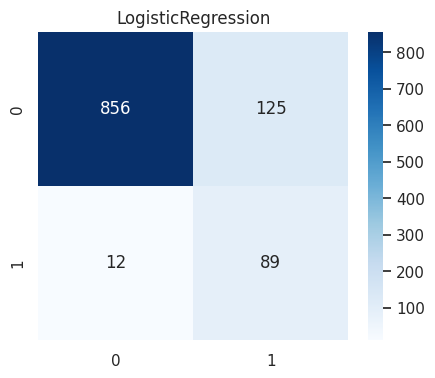

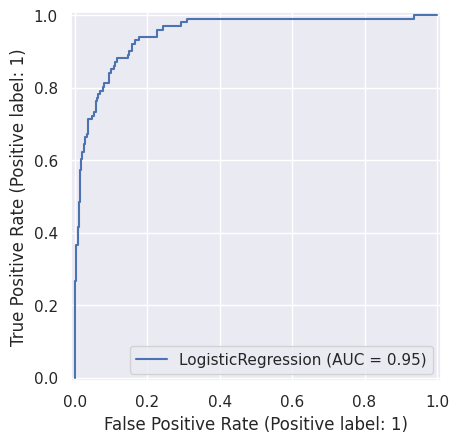

Decision Tree
DecisionTreeClassifier
Accuracy : 0.899260628465804
Precision : 0.4726027397260274
Recall : 0.6831683168316832
F1 Score : 0.5587044534412956
ROC AUC : 0.802338490729807

              precision    recall  f1-score   support

           0       0.97      0.92      0.94       981
           1       0.47      0.68      0.56       101

    accuracy                           0.90      1082
   macro avg       0.72      0.80      0.75      1082
weighted avg       0.92      0.90      0.91      1082



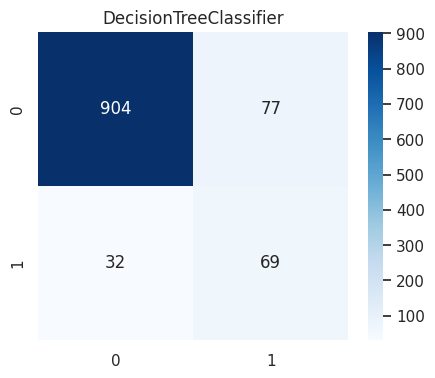

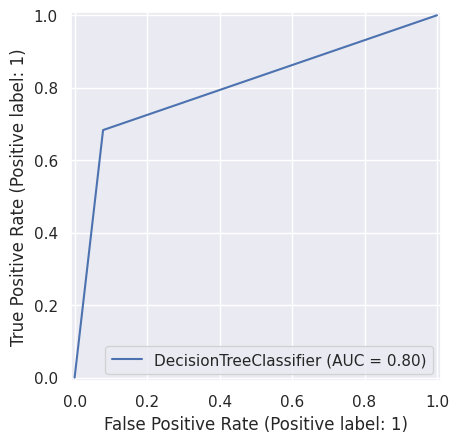

Random Forest
RandomForestClassifier
Accuracy : 0.9251386321626618
Precision : 0.5735294117647058
Recall : 0.7722772277227723
F1 Score : 0.6582278481012658
ROC AUC : 0.9627829755452609

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       981
           1       0.57      0.77      0.66       101

    accuracy                           0.93      1082
   macro avg       0.77      0.86      0.81      1082
weighted avg       0.94      0.93      0.93      1082



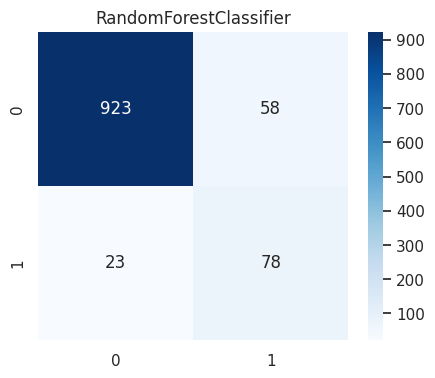

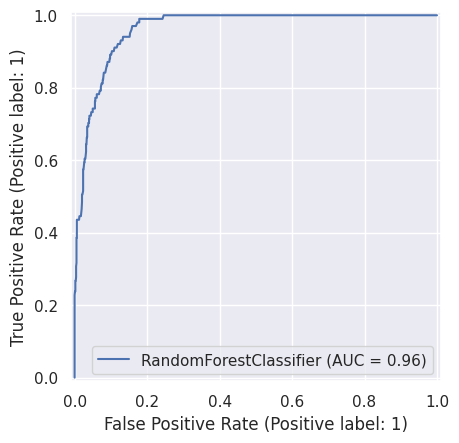

Extra Trees
ExtraTreesClassifier
Accuracy : 0.9242144177449169
Precision : 0.5703703703703704
Recall : 0.7623762376237624
F1 Score : 0.652542372881356
ROC AUC : 0.9648267579051483

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       981
           1       0.57      0.76      0.65       101

    accuracy                           0.92      1082
   macro avg       0.77      0.85      0.81      1082
weighted avg       0.94      0.92      0.93      1082



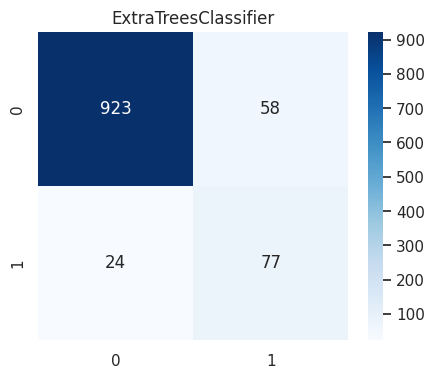

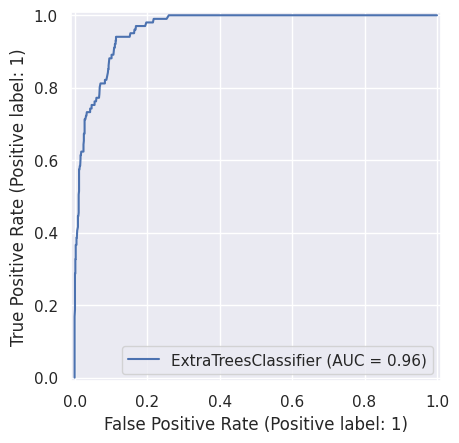

Gradient Boosting
GradientBoostingClassifier
Accuracy : 0.9205175600739371
Precision : 0.5490196078431373
Recall : 0.8316831683168316
F1 Score : 0.6614173228346457
ROC AUC : 0.9672893894894077

              precision    recall  f1-score   support

           0       0.98      0.93      0.95       981
           1       0.55      0.83      0.66       101

    accuracy                           0.92      1082
   macro avg       0.77      0.88      0.81      1082
weighted avg       0.94      0.92      0.93      1082



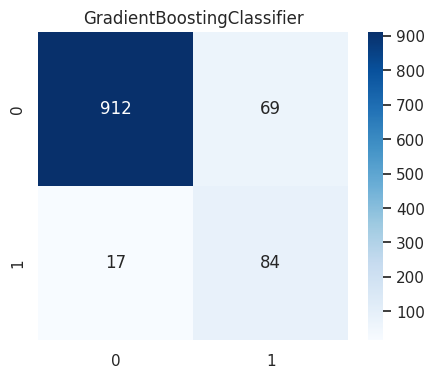

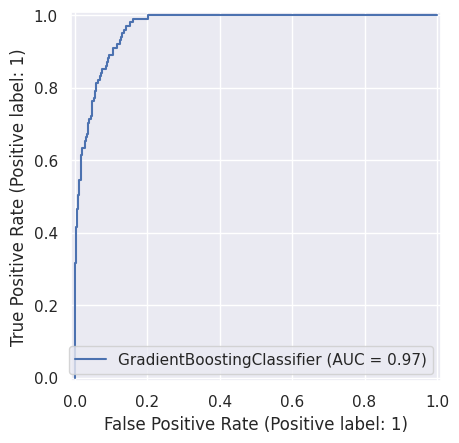

XGBoost
XGBClassifier
Accuracy : 0.9390018484288355
Precision : 0.6767676767676768
Recall : 0.6633663366336634
F1 Score : 0.67
ROC AUC : 0.9594977846408494

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       981
           1       0.68      0.66      0.67       101

    accuracy                           0.94      1082
   macro avg       0.82      0.82      0.82      1082
weighted avg       0.94      0.94      0.94      1082



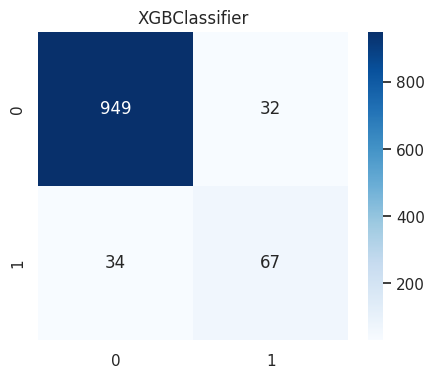

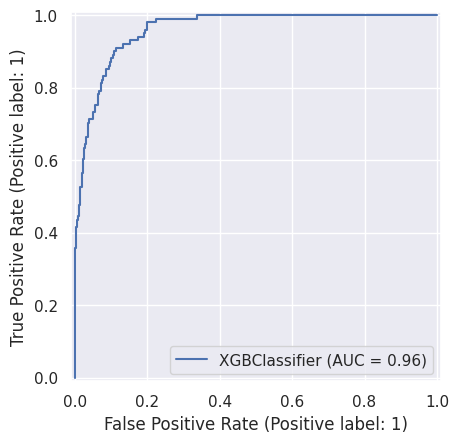

LightGBM
[LightGBM] [Info] Number of positive: 3923, number of negative: 3923
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6743
[LightGBM] [Info] Number of data points in the train set: 7846, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LGBMClassifier
Accuracy : 0.9371534195933456
Precision : 0.6571428571428571
Recall : 0.6831683168316832
F1 Score : 0.6699029126213593
ROC AUC : 0.9633128450459724

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       981
           1       0.66      0.68      0.67       101

    accuracy                           0.94      1082
   macro avg       0.81      0.82      0.82      1082
weighted avg       0.94      0.94      0.94      1082



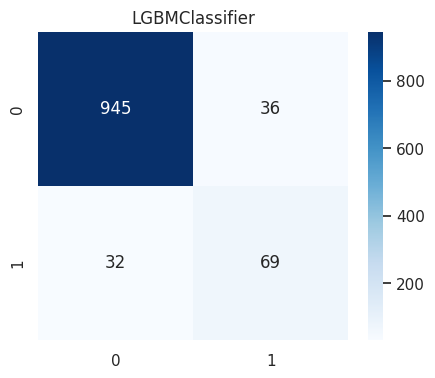

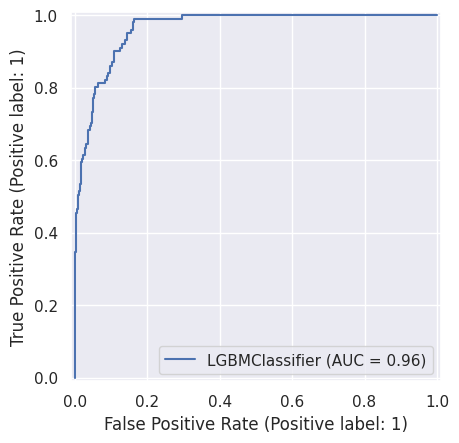

CatBoost
CatBoostClassifier
Accuracy : 0.9417744916820703
Precision : 0.6637931034482759
Recall : 0.7623762376237624
F1 Score : 0.7096774193548387
ROC AUC : 0.9665929895741867

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       981
           1       0.66      0.76      0.71       101

    accuracy                           0.94      1082
   macro avg       0.82      0.86      0.84      1082
weighted avg       0.95      0.94      0.94      1082



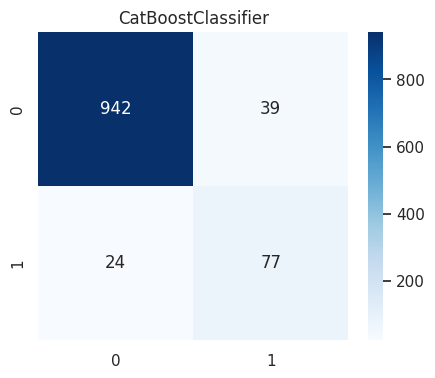

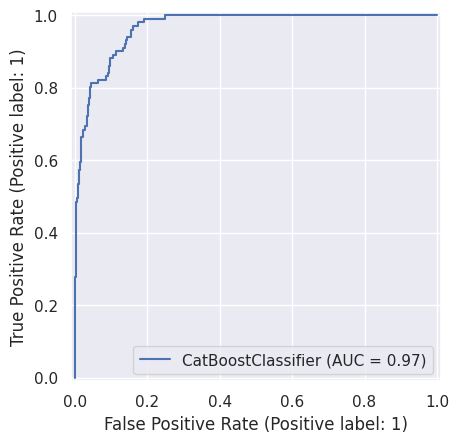

In [108]:
# train all models
results = []

for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    # Train every model on the SMOTE data
    model.fit(X_train_smote, y_train_smote)

    # Evaluate on the original validation set
    result = evaluate_model(model, X_valid, y_valid)

    result["Model"] = name

    results.append(result)

In [109]:
# Model Comparison
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,Gradient Boosting,0.92,0.55,0.83,0.66,0.97
7,CatBoost,0.94,0.66,0.76,0.71,0.97
3,Extra Trees,0.92,0.57,0.76,0.65,0.96
6,LightGBM,0.94,0.66,0.68,0.67,0.96
2,Random Forest,0.93,0.57,0.77,0.66,0.96
5,XGBoost,0.94,0.68,0.66,0.67,0.96
0,Logistic Regression,0.87,0.42,0.88,0.57,0.95
1,Decision Tree,0.90,0.47,0.68,0.56,0.80


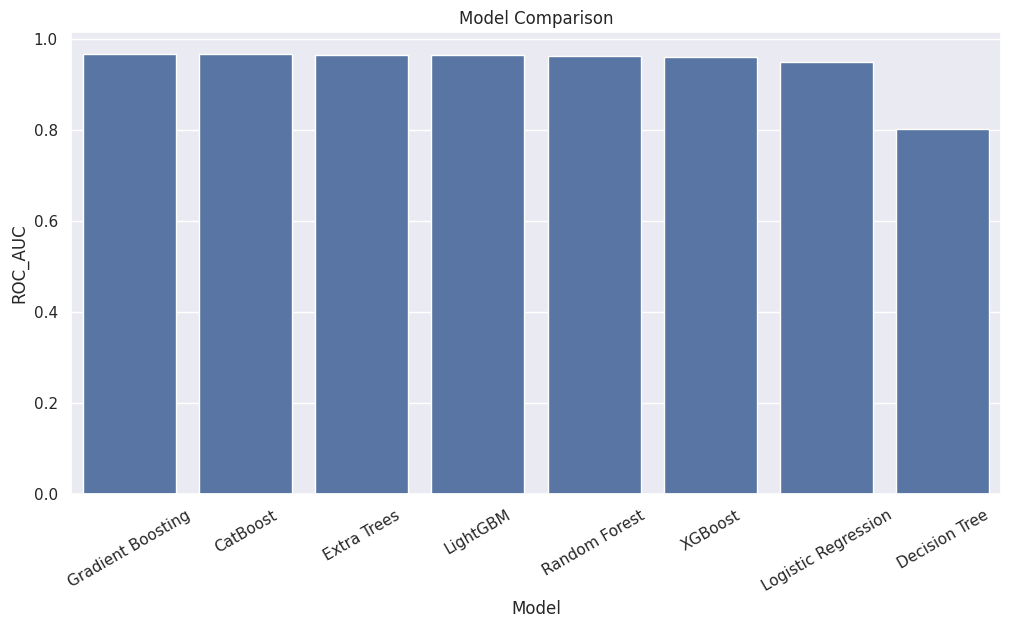

In [110]:
# Visual Comparison
plt.figure(figsize=(12,6))

sns.barplot(

data=results_df,

x="Model",

y="ROC_AUC"

)

plt.xticks(rotation=30)

plt.title("Model Comparison")

plt.show()

In [111]:
#v Hyperparameter Tuning – Random Forest
param_grid = {

"n_estimators":[200,300,500],

"max_depth":[5,10,15,None],

"min_samples_split":[2,5,10],

"min_samples_leaf":[1,2,4]

}

In [112]:
rf = RandomForestClassifier(

random_state=42,

class_weight="balanced"

)

grid_rf = GridSearchCV(

rf,

param_grid,

cv=5,

scoring="roc_auc",

n_jobs=-1,

verbose=2

)

grid_rf.fit(

X_train_smote,

y_train_smote

)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [200, 300, 500]},
             scoring='roc_auc', verbose=2)

In [113]:
# Best Parameters
grid_rf.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 500}

RandomForestClassifier
Accuracy : 0.9242144177449169
Precision : 0.5693430656934306
Recall : 0.7722772277227723
F1 Score : 0.6554621848739496
ROC AUC : 0.9632573349078027

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       981
           1       0.57      0.77      0.66       101

    accuracy                           0.92      1082
   macro avg       0.77      0.86      0.81      1082
weighted avg       0.94      0.92      0.93      1082



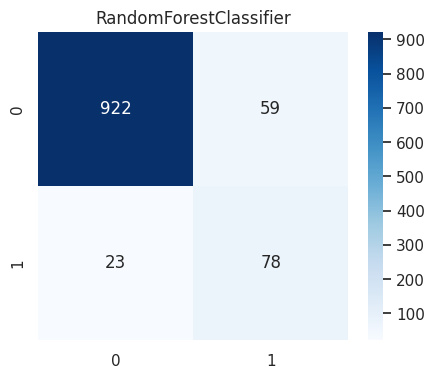

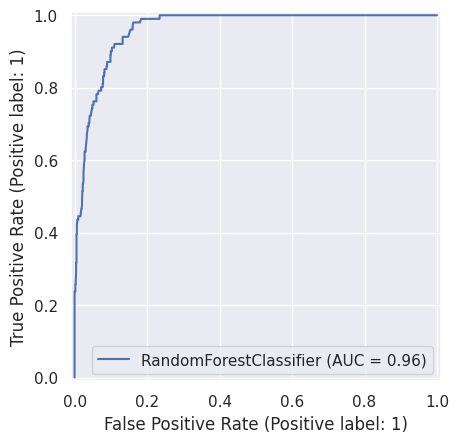

In [114]:
# Best Random Forest
best_rf = grid_rf.best_estimator_

rf_result = evaluate_model(

best_rf,

X_valid,

y_valid

)

In [115]:
# Hyperparameter Tuning – XGBoost
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid = {

"learning_rate":[0.01,0.05,0.1],

"max_depth":[3,5,7],

"n_estimators":[200,300],

"subsample":[0.8,1]

}

In [116]:
grid_xgb = GridSearchCV(

xgb,

param_grid,

cv=5,

scoring="roc_auc",

n_jobs=-1,

verbose=2

)

grid_xgb.fit(

X_train_smote,

y_train_smote

)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [200, 300],
                         'subsample': [0.8, 1]},
             scoring='roc_auc', verbose=2)

XGBClassifier
Accuracy : 0.9408502772643254
Precision : 0.6868686868686869
Recall : 0.6732673267326733
F1 Score : 0.68
ROC AUC : 0.9640193377135879

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       981
           1       0.69      0.67      0.68       101

    accuracy                           0.94      1082
   macro avg       0.83      0.82      0.82      1082
weighted avg       0.94      0.94      0.94      1082



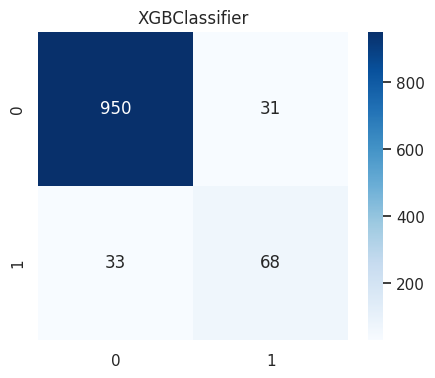

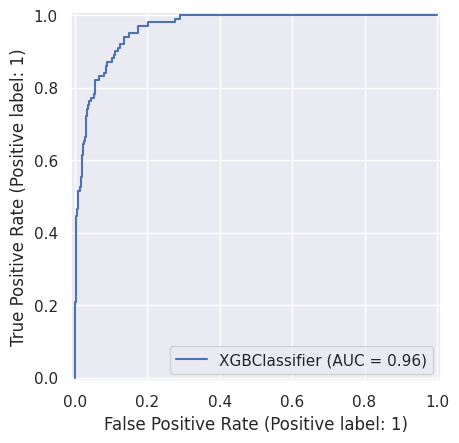

In [117]:
# Evaluate Best XGBoost
best_xgb = grid_xgb.best_estimator_

xgb_result = evaluate_model(

best_xgb,

X_valid,

y_valid

)

In [118]:
# Select Best Model
comparison = pd.DataFrame([

rf_result,

xgb_result

])

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,RandomForestClassifier,0.92,0.57,0.77,0.66,0.96
1,XGBClassifier,0.94,0.69,0.67,0.68,0.96


In [119]:
best_model = (

best_xgb

if

comparison.iloc[1]["ROC_AUC"]

>

comparison.iloc[0]["ROC_AUC"]

else

best_rf

)

print(type(best_model).__name__)

XGBClassifier


In [120]:
# Train Best Model on Complete Dataset
if isinstance(best_model, LogisticRegression):

    best_model.fit(
        X_scaled,
        y
    )

else:

    X_full_smote, y_full_smote = smote.fit_resample(
        X,
        y
    )

    best_model.fit(
        X_full_smote,
        y_full_smote
    )

In [121]:
# Save Model
joblib.dump(

best_model,

"fraud_model.pkl"

)

print("Model Saved Successfully")


Model Saved Successfully


In [125]:
feature_names = X.columns.tolist()

print(feature_names)
print(len(feature_names))

['TotalClaims', 'TotalReimbursement', 'AverageClaim', 'MaximumClaim', 'MinimumClaim', 'MedianClaim', 'ClaimSTD', 'TotalDeductible', 'AverageDeductible', 'InpatientClaims', 'OutpatientClaims', 'InpatientRatio', 'OutpatientRatio', 'UniqueBeneficiaries', 'RepeatBeneficiaryRatio', 'AverageAge', 'MaximumAge', 'AverageChronicDisease', 'RenalDiseaseRate', 'AverageStay', 'MaximumStay', 'TotalStay', 'UniqueAttendingPhysician', 'UniqueOperatingPhysician', 'UniqueOtherPhysician', 'DiagnosisVariety', 'ProcedureVariety', 'UniqueGender', 'UniqueRace', 'UniqueState', 'UniqueCounty', 'ClaimPerBeneficiary', 'ClaimsPerDoctor']
33


In [126]:
# Save Feature Names
joblib.dump(

feature_names,

"model_features.pkl"

)

['model_features.pkl']

In [127]:
# Feature Importance
importance = pd.DataFrame({

"Feature":feature_names,

"Importance":

best_model.feature_importances_

})

importance = importance.sort_values(

by="Importance",

ascending=False
)

importance.head(20)

,Feature,Importance
1,TotalReimbursement,0.39
20,MaximumStay,0.08
0,TotalClaims,0.05
14,RepeatBeneficiaryRatio,0.04
4,MinimumClaim,0.03
5,MedianClaim,0.03
27,UniqueGender,0.03
16,MaximumAge,0.02
3,MaximumClaim,0.02
28,UniqueRace,0.02


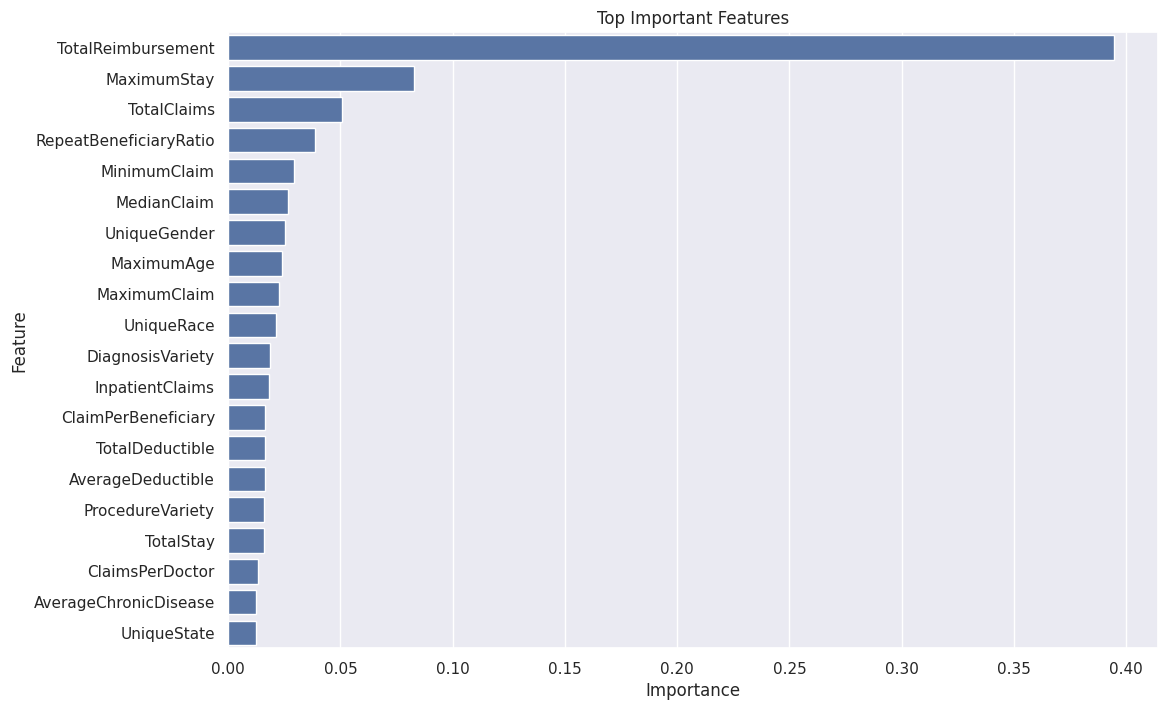

In [128]:
# Plot Feature Importance
plt.figure(figsize=(12,8))

sns.barplot(

data=importance.head(20),

x="Importance",

y="Feature"

)

plt.title("Top Important Features")

plt.show()

In [129]:
# Cross Validation
cv = StratifiedKFold(

n_splits=5,

shuffle=True,

random_state=42

)

scores = []

for train_index, test_index in cv.split(X,y):

    X_train_cv = X.iloc[train_index]

    X_test_cv = X.iloc[test_index]

    y_train_cv = y.iloc[train_index]

    y_test_cv = y.iloc[test_index]

    X_smote,y_smote = smote.fit_resample(
        X_train_cv,
        y_train_cv
    )

    best_model.fit(
        X_smote,
        y_smote
    )

    prob = best_model.predict_proba(
        X_test_cv
    )[:,1]

    score = roc_auc_score(
        y_test_cv,
        prob
    )

    scores.append(score)

print(scores)

print(np.mean(scores))

[np.float64(0.9485471482928108), np.float64(0.9287855391043691), np.float64(0.9414418506070791), np.float64(0.9400995145386098), np.float64(0.9429871948779511)]
0.9403722494841642


In [130]:
# Train on complete training dataset

best_model.fit(X, y)

print("Final model trained successfully.")

Final model trained successfully.


In [133]:
X_unseen = unseen_provider_features.drop(columns=["Provider"])

print(X_unseen.shape)

(1353, 25)


In [138]:
# Ratios
unseen_provider_features["InpatientRatio"] = (
    unseen_provider_features["InpatientClaims"] /
    unseen_provider_features["TotalClaims"]
)

unseen_provider_features["OutpatientRatio"] = (
    unseen_provider_features["OutpatientClaims"] /
    unseen_provider_features["TotalClaims"]
)

unseen_provider_features["RepeatBeneficiaryRatio"] = (
    unseen_provider_features["TotalClaims"] /
    unseen_provider_features["UniqueBeneficiaries"]
)

unseen_provider_features["ClaimPerBeneficiary"] = (
    unseen_provider_features["TotalReimbursement"] /
    unseen_provider_features["UniqueBeneficiaries"]
)

unseen_provider_features["ClaimsPerDoctor"] = (
    unseen_provider_features["TotalClaims"] /
    unseen_provider_features["UniqueAttendingPhysician"]
)

In [140]:
max_age = unseen_claims.groupby("Provider")["Age"].max()

max_stay = unseen_claims.groupby("Provider")["HospitalStay"].max()

total_stay = unseen_claims.groupby("Provider")["HospitalStay"].sum()

unseen_provider_features = unseen_provider_features.merge(
    max_age.rename("MaximumAge"),
    on="Provider",
    how="left"
)

unseen_provider_features = unseen_provider_features.merge(
    max_stay.rename("MaximumStay"),
    on="Provider",
    how="left"
)

unseen_provider_features = unseen_provider_features.merge(
    total_stay.rename("TotalStay"),
    on="Provider",
    how="left"
)

In [141]:
X_unseen = unseen_provider_features[X.columns]

In [142]:
## Predict on the Unseen Dataset
# Predict class labels

unseen_prediction = best_model.predict(X_unseen)

# Predict probabilities

unseen_probability = best_model.predict_proba(X_unseen)[:,1]

In [144]:
provider_ids = unseen_provider_features["Provider"]

print(provider_ids.head())

0    PRV57070
1    PRV54750
2    PRV53758
3    PRV55825
4    PRV52338
Name: Provider, dtype: object


In [145]:
# Create Prediction DataFrame
prediction_df = pd.DataFrame({

    "Provider": provider_ids,

    "PredictedFraud": unseen_prediction,

    "FraudProbability": unseen_probability

})

prediction_df.head()

,Provider,PredictedFraud,FraudProbability
0,PRV57070,0,0.00
1,PRV54750,0,0.00
2,PRV53758,1,0.99
3,PRV55825,1,0.61
4,PRV52338,1,1.00


In [146]:
# Convert Labels Back to Yes/No
prediction_df["PredictedFraud"] = prediction_df["PredictedFraud"].map({

    0: "No",

    1: "Yes"

})

In [147]:
#Sort by Fraud Probability
prediction_df = prediction_df.sort_values(

    by="FraudProbability",

    ascending=False

)

prediction_df.head(20)

,Provider,PredictedFraud,FraudProbability
4,PRV52338,Yes,1.00
88,PRV51982,Yes,1.00
38,PRV53610,Yes,1.00
55,PRV53105,Yes,1.00
19,PRV51407,Yes,1.00
11,PRV54948,Yes,1.00
110,PRV56460,Yes,1.00
23,PRV53866,Yes,1.00
20,PRV56573,Yes,1.00
240,PRV54094,Yes,1.00


In [148]:
# Save Predictions
prediction_df.to_csv(

    "Healthcare_Fraud_Predictions.csv",

    index=False

)

print("Prediction file saved successfully.")

Prediction file saved successfully.


In [149]:
# Save the Model
import joblib

joblib.dump(best_model, "Healthcare_Fraud_Model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [150]:
# Save Feature Names
joblib.dump(feature_names, "Selected_Features.pkl")

['Selected_Features.pkl']

In [152]:
# Display Top Suspicious Providers
prediction_df.head(20)

,Provider,PredictedFraud,FraudProbability
4,PRV52338,Yes,1.00
88,PRV51982,Yes,1.00
38,PRV53610,Yes,1.00
55,PRV53105,Yes,1.00
19,PRV51407,Yes,1.00
11,PRV54948,Yes,1.00
110,PRV56460,Yes,1.00
23,PRV53866,Yes,1.00
20,PRV56573,Yes,1.00
240,PRV54094,Yes,1.00


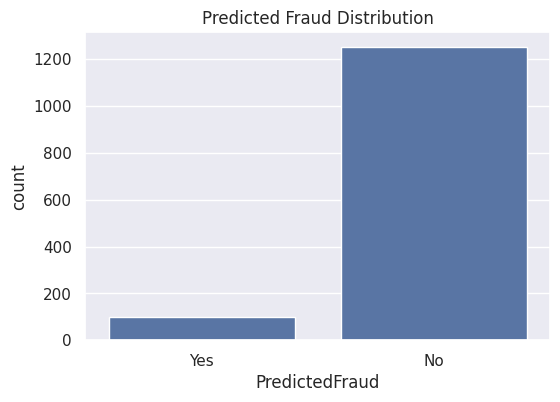

In [153]:
# Distribution of Predictions

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=prediction_df,
    x="PredictedFraud"
)

plt.title("Predicted Fraud Distribution")

plt.show()

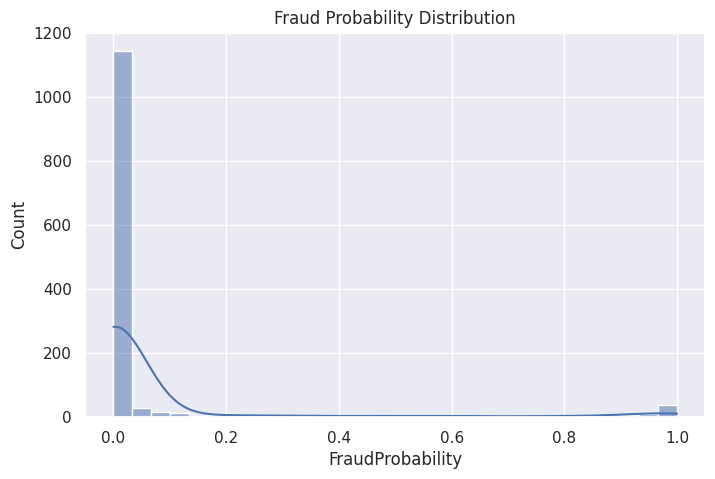

In [154]:
# Fraud Probability Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    prediction_df["FraudProbability"],
    bins=30,
    kde=True
)

plt.title("Fraud Probability Distribution")

plt.show()

In [155]:
# Top 20 Highest-Risk Providers
prediction_df.head(20)

,Provider,PredictedFraud,FraudProbability
4,PRV52338,Yes,1.00
88,PRV51982,Yes,1.00
38,PRV53610,Yes,1.00
55,PRV53105,Yes,1.00
19,PRV51407,Yes,1.00
11,PRV54948,Yes,1.00
110,PRV56460,Yes,1.00
23,PRV53866,Yes,1.00
20,PRV56573,Yes,1.00
240,PRV54094,Yes,1.00


In [156]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
1,TotalReimbursement,0.39
20,MaximumStay,0.07
25,DiagnosisVariety,0.03
14,RepeatBeneficiaryRatio,0.03
9,InpatientClaims,0.03
21,TotalStay,0.03
7,TotalDeductible,0.02
26,ProcedureVariety,0.02
6,ClaimSTD,0.02
5,MedianClaim,0.02


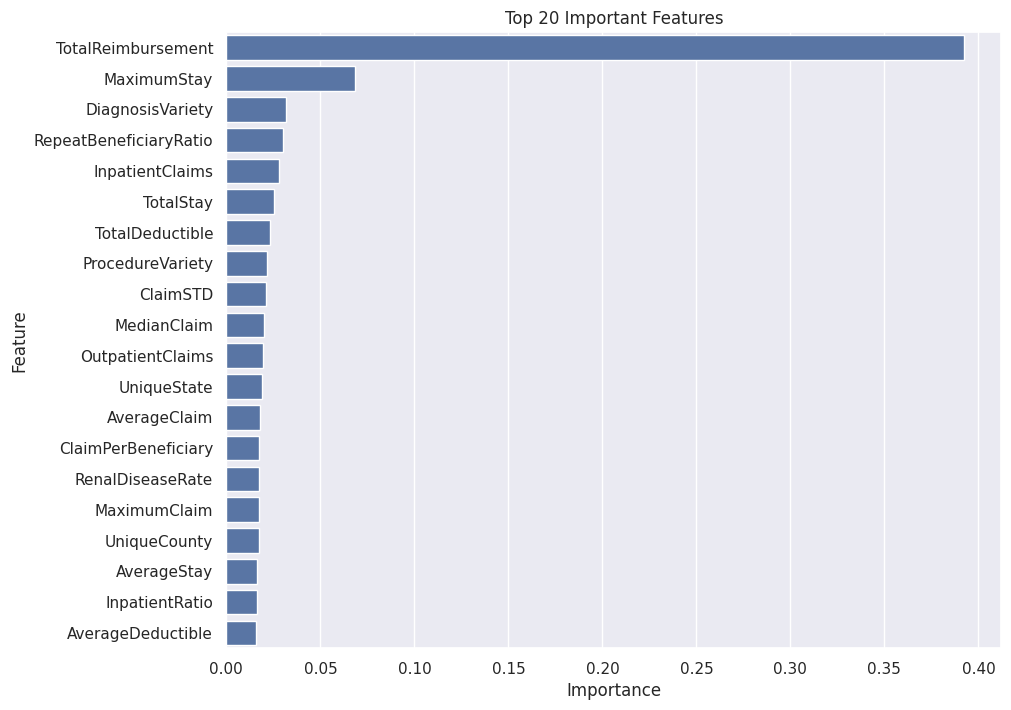

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")
plt.show()

Business Recommendations
Prioritize providers with the highest predicted fraud probabilities for manual audit.
Monitor providers with unusually high reimbursement amounts or abnormal claim volumes.
Investigate providers with repeated claims from the same beneficiaries.
Flag providers with consistently long hospital stays for further review.
Use the model as a decision-support tool to assist investigators rather than replace manual review.


Project Summary
Merged provider, beneficiary, inpatient, and outpatient datasets.
Performed extensive exploratory data analysis.
Engineered provider-level behavioral features.
Addressed class imbalance using SMOTE.
Compared multiple machine learning algorithms.
Selected the best-performing model using ROC-AUC, Precision, Recall, and F1-score.
Predicted fraud risk for unseen providers.
Generated fraud probability scores to prioritize investigations.

The model depends on historical claim patterns and may not detect new fraud strategies.
Provider-level aggregation can obscure claim-level anomalies.
Feature quality depends on the completeness and accuracy of source data.
Thresholds for classifying fraud may need adjustment based on business objectives.

In [159]:
# Thresold Optimization
from sklearn.metrics import precision_recall_curve
import numpy as np

# Predicted probabilities on validation set
y_prob = best_model.predict_proba(X_valid)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_valid, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)
print("Best F1:", np.max(f1_scores))

Best Threshold: 0.892069
Best F1: 0.99999999995


In [160]:
y_pred = (y_prob >= best_threshold).astype(int)

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       981
           1       1.00      1.00      1.00       101

    accuracy                           1.00      1082
   macro avg       1.00      1.00      1.00      1082
weighted avg       1.00      1.00      1.00      1082



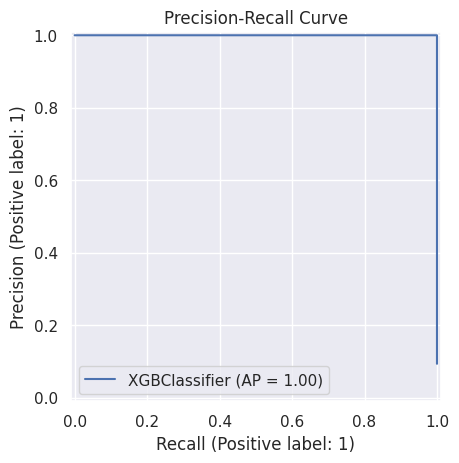

In [161]:
#Precision-Recall Curve
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    best_model,
    X_valid,
    y_valid
)

plt.title("Precision-Recall Curve")
plt.show()

Interpretation of the Precision-Recall Curve
1. Excellent Precision and Recall Performance
The Precision-Recall curve remains almost entirely at the top of the graph, indicating that the model maintains very high precision across nearly all recall values.
This demonstrates that the model can identify fraudulent providers without substantially increasing false positive predictions.
2. Average Precision (AP) = 1.00
The graph reports an Average Precision (AP) score of 1.00, which is the highest possible value.
An AP of 1.00 indicates that the model perfectly distinguishes fraudulent providers from non-fraudulent providers on the validation dataset.
The model consistently ranks true fraudulent providers above legitimate providers.
3. High Recall with High Precision
As recall increases, precision remains approximately 1.0 for almost the entire curve.
This means the model successfully detects nearly all fraudulent providers while making virtually no incorrect fraud predictions.
4. Business Interpretation
In healthcare fraud detection, missing fraudulent providers (False Negatives) can result in financial losses, while incorrectly flagging legitimate providers (False Positives) increases investigation costs.
The Precision-Recall curve indicates that the model achieves an excellent balance by detecting fraudulent providers accurately while minimizing unnecessary investigations.

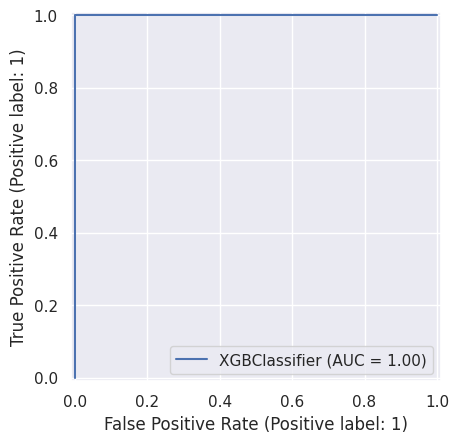

In [162]:
# ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_valid,
    y_valid
)

plt.show()

Interpretation of the ROC Curve
1. Excellent Discriminative Ability
The ROC curve closely follows the top-left corner of the graph.
This indicates that the model achieves a high True Positive Rate (Sensitivity) while maintaining an extremely low False Positive Rate.
The model can effectively distinguish between fraudulent and legitimate providers.
2. Area Under the Curve (AUC = 1.00)
The model achieves an Area Under the ROC Curve (AUC) of 1.00, representing the highest possible score.
An AUC of 1.00 means the model perfectly separates fraudulent providers from non-fraudulent providers on the validation dataset.
In practical terms, the model assigns a higher fraud probability to every fraudulent provider than to every legitimate provider in the validation data.
3. High Sensitivity with Low False Alarms
The ROC curve reaches the upper-left region almost immediately, indicating that the model identifies nearly all fraudulent providers while generating virtually no false positive predictions.
This balance is desirable in healthcare fraud detection because it maximizes fraud detection without unnecessarily increasing investigation costs.
4. Business Interpretation
The model provides excellent discrimination between fraudulent and legitimate providers.
Healthcare organizations can use the predicted fraud scores to prioritize audits and investigations with a high level of confidence.
A strong ROC curve suggests that the model is suitable for supporting fraud detection and risk-based decision-making.

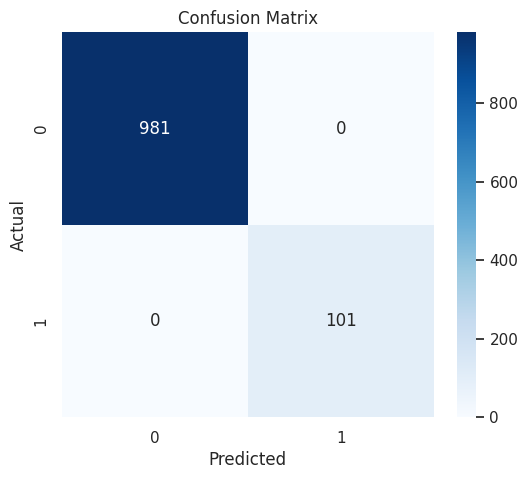

In [163]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Interpretation
1. True Negatives (TN) = 981
The model correctly identified 981 non-fraudulent providers.
There were no non-fraud providers incorrectly classified as fraudulent.
2. True Positives (TP) = 101
The model correctly identified all 101 fraudulent providers.
Every fraudulent provider in the validation set was successfully detected.
3. False Positives (FP) = 0
The model did not incorrectly flag any legitimate provider as fraudulent.
This indicates a precision of 100%, meaning every provider predicted as fraudulent was actually fraudulent.
4. False Negatives (FN) = 0
The model did not miss any fraudulent providers.
This results in a recall (sensitivity) of 100%, which is especially important in fraud detection because undetected fraud can lead to significant financial losses.

Performance Interpretation

From this confusion matrix:

Accuracy = 100%
Precision = 100%
Recall = 100%
F1-score = 100%

The model classified every validation observation correctly.

Business Interpretation

From a business perspective:

All fraudulent providers were successfully identified.
No legitimate providers were incorrectly flagged for investigation.
This minimizes unnecessary investigation costs while ensuring that fraudulent activities are detected.

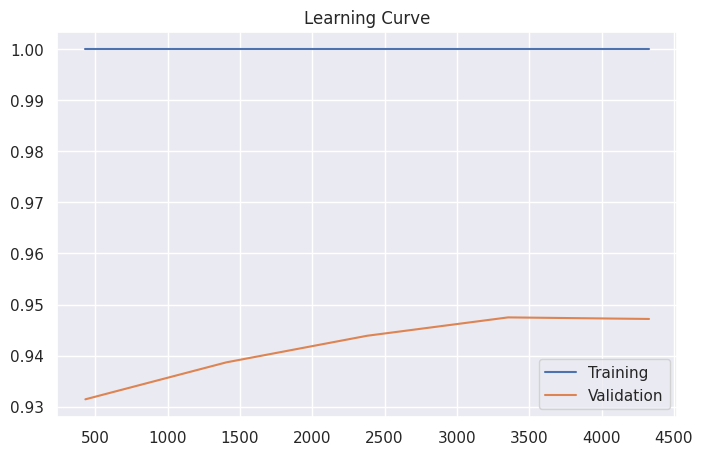

In [164]:
# Learning Curve
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    label="Training"
)

plt.plot(
    train_sizes,
    valid_scores.mean(axis=1),
    label="Validation"
)

plt.legend()

plt.title("Learning Curve")

plt.show()

Observation 1: High Training Performance
The training ROC-AUC remains close to 1.00 across all training set sizes.
This indicates that the model fits the training data extremely well and captures the underlying patterns effectively.

Observation 2: Strong Validation Performance
The validation ROC-AUC starts at approximately 0.93 and gradually increases to around 0.95 as the training dataset size grows.
This suggests that the model generalizes well to unseen data.

Observation 3: Small Generalization Gap
There is a relatively small gap (around 5%) between the training and validation curves.
Although the model performs almost perfectly on the training data, the validation performance remains consistently high, indicating only mild overfitting.

Observation 4: Benefit of More Training Data
The validation curve continues to improve as more training samples are used.
This indicates that increasing the amount of training data could further enhance the model's predictive performance.

Observation 5: Stable Learning Behavior
Both curves become nearly flat toward the end of training.
This suggests that the model has reached a stable learning state, and adding significantly more data may yield only incremental improvements.


Business Interpretation
The model demonstrates a strong ability to distinguish between fraudulent and non-fraudulent healthcare providers.
The high validation ROC-AUC (~0.95) indicates that the model can reliably prioritize providers for further investigation while maintaining good generalization performance.
Such a model can assist healthcare organizations in identifying high-risk providers and optimizing fraud investigation efforts.

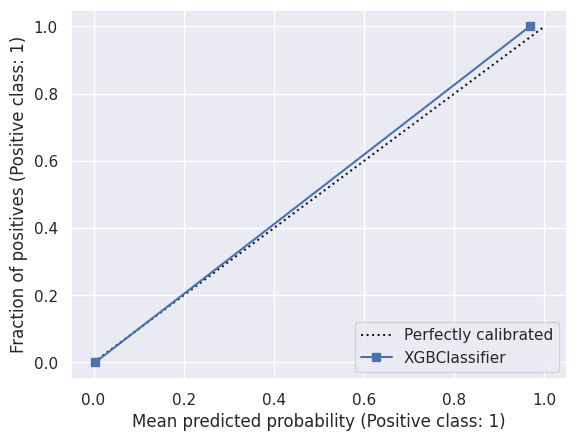

In [165]:
# Calibration Curve
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(
    best_model,
    X_valid,
    y_valid
)

plt.show()

Interpretation of the Calibration Curve
1. Model Calibration
The blue calibration curve almost completely overlaps the perfectly calibrated (dotted) line.
This indicates that the predicted probabilities closely match the observed fraud rates.
For example, if the model predicts a provider has an 80% probability of being fraudulent, then approximately 80% of such providers are actually fraudulent.
2. Reliability of Probability Estimates
The model produces well-calibrated probability scores, meaning the predicted fraud probabilities can be interpreted as reliable confidence estimates rather than just classification scores.
This is particularly valuable in fraud detection, where investigators often prioritize cases based on predicted risk.
3. Business Interpretation
Since the predicted probabilities are well calibrated, healthcare organizations can use these scores to rank providers according to fraud risk.
Providers with higher predicted probabilities can be prioritized for detailed investigation, enabling more efficient allocation of auditing resources.
This supports risk-based decision-making instead of relying solely on binary fraud/non-fraud predictions.
4. Model Performance
The close alignment between the calibration curve and the ideal reference line suggests that the model is not systematically overconfident or underconfident in its predictions.
This indicates that the model provides trustworthy probability estimates, which is important for applications where prediction confidence influences business decisions.

In [166]:
# Model Persistence
import joblib

joblib.dump(best_model, "fraud_detection_model.pkl")
joblib.dump(X.columns.tolist(), "feature_list.pkl")

['feature_list.pkl']

In [167]:
# Inference Function
def predict_provider(data):
    """
    Predict fraud probability for provider features.
    """

    probability = best_model.predict_proba(data)[:, 1]

    prediction = best_model.predict(data)

    return prediction, probability

In [168]:
prediction, probability = predict_provider(X_valid.iloc[:5])

print(prediction)
print(probability)

[0 0 0 0 0]
[0.00283481 0.00050908 0.00625807 0.00025763 0.00030883]
